# 1 Introduction mnist

## A simple classifier for mnist digits

mnist is a standard data set of hand-written digits widely used in machine learning.


We will explore the data set and write a simple classifier.


We will define a template for each digit and predict a label for an unseen image by judging to which of the 10 digit templates the image is the most similar.





In [ ]:
#@title Load mnist data

from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from tqdm import tqdm



# load mnist data separated into images (x) and labels (y)
# and separated into training and test data

(x_train, y_train), (x_test, y_test) = mnist.load_data()



# label2id is a dictionary with digit as key and
# a list of ids for that digits

label2id = defaultdict(list)
for i,y in enumerate(y_train):
  label2id[y].append(i)



# show takes a list of images and list of labels and
# plots them next to each other
# optionally predicted labels y_pred can be defined

def show(x,y, y_pred=None):
  n = len(x)
  plt.figure(figsize=(n, 1))        # plot n digits next to each other
  for i in range(n):
    plt.subplot(1, n, i+1)
    plt.axis('off')
    plt.imshow(x[i].reshape(28,28), cmap='gray')

    if y_pred is not None:          # print true and poredicted label
      plt.title("%d/%d"%(y[i],y_pred[i]))
    elif y!=[]:
      plt.title("%d"%y[i])
  plt.show()



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


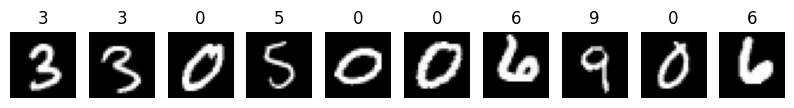

In [ ]:
#@title Show a random example from mnist


# return a tuple of an image and its label randomly selected from the training data

def random_xy():
  i = np.random.randint(0, len(x_train))
  return (x_train[i], y_train[i])

def random_xys(n):
  xs,ys=[],[]
  for _ in range(n):
    x,y = random_xy()
    xs.append(x)
    ys.append(y)
  return (xs,ys)


# select 10 random images and labels in lists xs, ys and display them with show


show(*random_xys(10))

# How to represent the images?

Gray scale from 0 (black) to 255 (white) or just black and white? Where to set a threshold to convert gray scale to b/w?

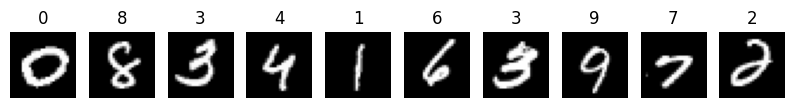

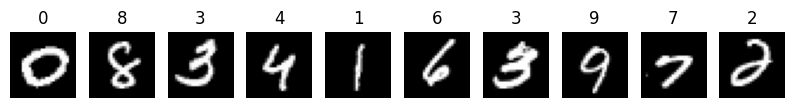

In [ ]:
#@title Turn gray to black/white

xs,ys = random_xys(10)
show(xs,ys)

threshold = 1 #@param {type:"number"}
binary = False #@param {type:"boolean"}

def bw(img, threshold):
  for i in range(28):
    for j in range(28):
      if img[i,j]>threshold:
        if binary: img[i,j]=255
      else:
        img[i,j]=0
  return img

for i in range(len(xs)):
  xs[i]=bw(xs[i], threshold)

show(xs,ys)




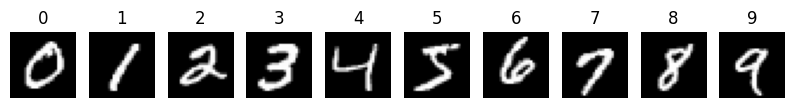

In [ ]:
#@title Select template. Pick first or pick randomly

# return a tutple with lists of 10 images and their labels,
# which will serve as templates for the digits

random = False #@param{type:"boolean"}

def select_templates(random=True):

  x_template = []
  y_template = []

  for label,ids in sorted(label2id.items()):
    if random:
      i = np.random.randint(0, len(label2id[label]))
      x_template.append(x_train[ids[i]])
    else:
      x_template.append(x_train[ids[0]])
    y_template.append(label)

  return x_template, y_template



# Show the selected template images

x_template, y_template = select_templates(random=random)
show(x_template, y_template)


In [ ]:
#@title Define distance

# define the distance between two images
# as the pixel-wise euclidean distance
#
# Proceed by turning the images, which are arrays of numbers, into vectors with flatten
# and then compute the distance using numpy.linalg.norm to compute Euclidean distance

def dist(img1,img2):
  v1 = img1.flatten()
  v2 = img2.flatten()
  return np.linalg.norm(v1-v2)

def cosine_similarity(img1, img2):
    v1 = img1.flatten()
    v2 = img2.flatten()
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))


def dist_binary_intersection(img1,img2):
  v1 = img1.flatten()
  v2 = img2.flatten()
  # range is 0 = black, 255 white. Most pixels are 0

  count = np.dot((v1 >= threshold).astype(int), (v2 >= threshold).astype(int))
  #count_slow = sum([1 for i1,i2 in zip(v1,v2) if i1>=threshold and i2>=threshold])

  # 784 minus sum to make small value best
  return 784-count

# Pick two random images and calculate their distance and show them

x1,y1 = random_xy()
x2,y2 = random_xy()
print(f"Euclidean distance {dist(x1,x2)}")
print(f"Intersection on binary representation {dist_binary_intersection(x1,x2)}")
show([x1,x2],[y1,y2])


Euclidean distance 2672.9083411145994


NameError: name 'threshold' is not defined

In [ ]:
#@title Predict with templates. Euclidean distance or binary intersection

# predict takes templates and an image as input
# and calculates which template is the most similar
# to the image and returns the label of that template

euclidean = True #@param{type:"boolean"}

def predict(x_template, y_template, x, y, dist=dist):

  y_best, dist_best = -1, np.inf

  # iterate through all templates (zip turns two lists into a list of pairs)
  for x_t,y_t in zip(x_template, y_template):
    d = dist(x_t, x)      # distance of template and image
    if d<dist_best:       # is distnace better than current best distance?
      dist_best = d       # yes, then store it
      y_best = y_t
  return y_best           # return label of template with best distance


# test_all takes templates as parameters and
# predicts the label for each image in the test data set

def test_all(x_template, y_template, dist=dist):

  tp=0    # correct predictions
  fp=[]   # wrong rpedictions

  for x,y in tqdm(zip(x_test, y_test)):             # iterate through all training example. tqdm displays a progress bar

    y_pred = predict(x_template, y_template, x, y, dist)  # predict label for test image

    if y_pred == y:                                 # correct or wrong?
      tp+=1
    else:
      fp.append((x,y,y_pred))

  print("\n\n%d out of %d (%.2f%%) correct predictions"%(tp, len(x_test), 100*tp/len(x_test)))

  return fp                                         # return all misclassified images for exploration


if euclidean:
  fp = test_all(x_template, y_template, dist=dist)
else:
  fp = test_all(x_template, y_template, dist=dist_binary_intersection)


NameError: name 'x_template' is not defined

In [ ]:
#@title Misclassified

# Show 10 randomly selected misclassified examples

# fp is a list of tuples image, label, predicted label
# zip and star * turn it into the 3 lists of images, labels, predicted labels
# as needed for the show function


def show_misclassified(fp):

  # Pick a random index in the fp1
  fr = np.random.randint(0, len(fp)-10)

  # Display 10 images
  show(*zip(*fp[fr:fr+10]))



show_misclassified(fp)

NameError: name 'fp' is not defined

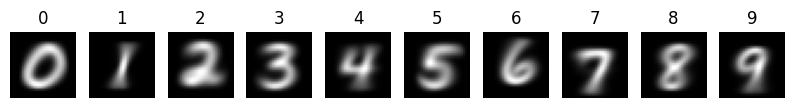

10000it [00:01, 9437.26it/s]



8203 out of 10000 (82.03%) correct predictions


In [ ]:
from sys import executable
#@title Average template. Euclidean distance or size of intersection

# Can we do better by defining a template which averages images per label
# Per label, we iterate through the training data and compute the average pixel value

euclidean = True #@param{type:"boolean"}

def average_template():

  x_template = []
  y_template = []

  # iterate through all 10 labels with their ids
  for y,ids in sorted(label2id.items()):

    x = np.zeros((28,28))   # init the average image x

    for i in ids:           # add all images for the label to x
      x += x_train[i]

    x /= len(ids)           # devide x by number of ids processed

    x_template.append(x)
    y_template.append(y)

  return x_template, y_template



x_avg_template, y_avg_template = average_template()

show(x_avg_template, y_avg_template)

if euclidean:
  fp_avg = test_all(x_avg_template, y_avg_template, dist=dist)
else:
  fp_avg = test_all(x_avg_template, y_avg_template, dist=dist_binary_intersection)


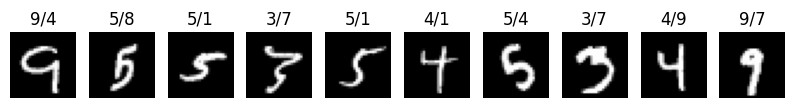

In [ ]:
#@title Misclassified with average template

# show some misclassfied images

show_misclassified(fp_avg)

<Axes: xlabel='True label', ylabel='Predicted label'>

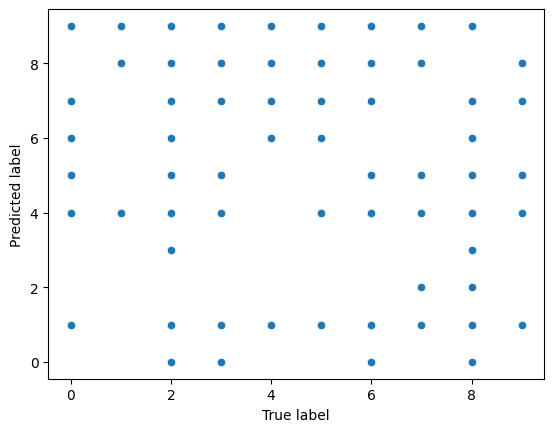

In [ ]:
#@title Known label (x) vs. predicted label (y). Are there false positives for all combinations?

x,y,y2 = zip(*fp)
import seaborn as sns
plt.xlabel("True label")
plt.ylabel("Predicted label")
sns.scatterplot(x=y, y=y2)

In [ ]:
#@title How many black pixels are there? Is it worth it to use a sparse representation?

black_pixels = 0
for x in x_train:
  black_pixels += np.sum(x == 0)

p = 100*black_pixels / (len(x_train) * 784)

print("%.2f%% of all pixels  are black"%(p))




80.88% of all pixels  are black


# K-nearest neighbour search for the mnist images

max_x_train is the number of training examples that are indexed. Maximum is 60.000
k should range form 3 to 30.
Search annoy by euclidean distance or cosine similarity.

In [ ]:
#@title k-nearest neighbours with Annoy. Build index

max_x_train = 100000 #@param
euclidean = True #@param{type:"boolean"}


import numpy as np
import time


try:
  from annoy import AnnoyIndex
except:
  !pip install annoy
  from annoy import AnnoyIndex





# pretty print for duration of running code
def sec2str(sec):

  minute, hour = 60, 60*60

  if   sec <= 1: return "less than 1 sec"
  elif sec <= minute: return "less than 1 min"
  elif sec < 2*minute: return "1:%02d min"%(int(sec)-minute)
  elif sec <= hour: return "%d:%02d min"%(int(sec/minute), int((sec%minute)))

  return "%d:%02d hours"%(int(sec/hour), (int(sec%hour)/minute))





start=time.time()

num_features = 784
if euclidean:
  index = AnnoyIndex(num_features, 'euclidean')
else:
  index = AnnoyIndex(num_features, 'angular')

for i, img in enumerate(x_train):
    if i<max_x_train:
      index.add_item(i, img.flatten())

index.build(10) # parameter = number of internal trees

print("\nIndexing %d took %s"%(max_x_train, sec2str(time.time()-start)))



Indexing 100000 took less than 1 min


4322it [00:03, 1371.73it/s]

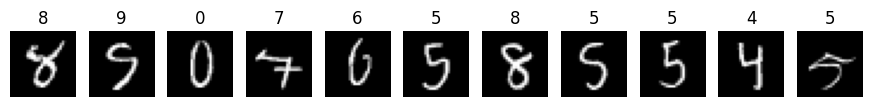

10000it [00:07, 1282.37it/s]




9502 out of 10000 (95.02%) correct predictions


Majority vote (how frequent is best label among  all k labels)
3: 12
4: 72
5: 215
6: 242
7: 252
8: 328
9: 620
10: 8259


How many different labels are there in the k labels
1: 8259
2: 1222
3: 370
4: 121
5: 26
6: 1
7: 1
Predicting all test examples took less than 1 min


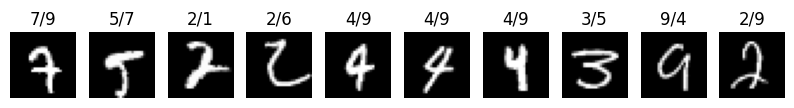

Ids of misclassified images:
[8, 61, 63, 77, 92, 115, 119, 124, 151, 195, 233, 241, 247, 259, 266, 300, 318, 320, 321, 341, 358, 362, 381, 403, 443, 444, 445, 447, 460, 464, 478, 479, 495, 543, 551, 553, 565, 578, 582, 583, 591, 603, 613, 628, 646, 659, 689, 691, 692, 707, 717, 740, 760, 791, 839, 844, 877, 882, 924, 938, 939, 947, 950, 951, 965, 1003, 1014, 1032, 1039, 1062, 1068, 1092, 1107, 1112, 1114, 1128, 1173, 1178, 1184, 1192, 1194, 1226, 1228, 1232, 1234, 1247, 1260, 1270, 1283, 1289, 1299, 1319, 1325, 1326, 1337, 1356, 1364, 1378, 1406, 1425, 1465, 1496, 1500, 1522, 1530, 1549, 1553, 1559, 1571, 1584, 1601, 1626, 1640, 1641, 1681, 1709, 1716, 1717, 1718, 1721, 1737, 1751, 1754, 1774, 1781, 1790, 1813, 1823, 1843, 1850, 1855, 1878, 1901, 1903, 1911, 1938, 1952, 1968, 1970, 1984, 2035, 2043, 2044, 2052, 2053, 2063, 2070, 2082, 2098, 2099, 2109, 2129, 2130, 2135, 2168, 2177, 2182, 2185, 2186, 2197, 2224, 2266, 2272, 2292, 2293, 2298, 2299, 2325, 2326, 2339, 2351, 2358, 2369, 238

In [ ]:
#@title k-nearest neighbours with Annoy. Run prediction

k=10 #@param{type:"number"}

from collections import Counter

def most_frequent_element(lst):
    return Counter(lst).most_common(1)[0][0]




def predict_annoy(x,k=10):
  best_k_j = index.get_nns_by_vector(x.flatten(), k) # get the k most similar images to x
  return best_k_j

def test_all_annoy(k):

  tp=0    # correct predictions
  fp=[]   # wrong predictions

  majority = defaultdict(int)
  unique_digits = defaultdict(int)

  for i,(x,y) in tqdm(enumerate(zip(x_test, y_test))):             # iterate through all test example

    best_k_j = predict_annoy(x,k=k)  # predict k nearest training images
    best_k_y_pred = [y_train[j] for j in best_k_j]     # get labels of these k images
    y_pred = most_frequent_element(best_k_y_pred)        # return the most frequent label



    majority[best_k_y_pred.count(y_pred)]+=1
    unique_digits[len(set(best_k_y_pred))]+=1
    if len(set(best_k_y_pred)) == 7:
      show([x]+[x_train[j] for j in best_k_j], [y]+best_k_y_pred)

    if y_pred == y:                                 # correct or wrong?
      tp+=1
    else:
      fp.append((i,x,y,y_pred))

  print("\n\n%d out of %d (%.2f%%) correct predictions"%(tp, len(x_test), 100*tp/len(x_test)))

  print("\n\nMajority vote (how frequent is best label among  all k labels)")
  for k,v in sorted(majority.items()):
    print("%d: %d"%(k,v))

  print("\n\nHow many different labels are there in the k labels")
  for k,v in sorted(unique_digits.items()):
    print("%d: %d"%(k,v))


  return fp                                         # return all misclassified images for exploration


start = time.time()
fp_annoy=test_all_annoy(k)
print("Predicting all test examples took %s"%(sec2str(time.time()-start)))

ids = [x[0] for x in fp_annoy]

fr = np.random.randint(0, len(fp_annoy)-10)
show(*zip(*[(x[1], x[2], x[3]) for x in fp_annoy[fr:fr+10]])
)

print("Ids of misclassified images:")
print(ids)


In [ ]:
e1=set([8, 63, 65, 92, 115, 151, 241, 266, 268, 300, 318, 320, 321, 341, 358, 381, 412, 445, 447, 460, 464, 479, 542, 543, 551, 578, 582, 583, 591, 646, 655, 689, 691, 717, 740, 791, 839, 844, 877, 881, 924, 936, 938, 939, 947, 1003, 1014, 1026, 1039, 1055, 1062, 1082, 1089, 1107, 1112, 1114, 1178, 1192, 1226, 1228, 1232, 1242, 1247, 1260, 1289, 1299, 1319, 1325, 1328, 1356, 1364, 1378, 1414, 1422, 1425, 1447, 1465, 1469, 1476, 1496, 1500, 1522, 1527, 1530, 1549, 1559, 1626, 1641, 1681, 1709, 1717, 1718, 1721, 1737, 1754, 1774, 1781, 1782, 1790, 1813, 1855, 1878, 1901, 1903, 1911, 1955, 1968, 1970, 1984, 2004, 2040, 2044, 2052, 2053, 2058, 2063, 2073, 2093, 2098, 2105, 2109, 2130, 2135, 2168, 2177, 2182, 2233, 2237, 2266, 2272, 2288, 2292, 2293, 2298, 2308, 2314, 2339, 2369, 2374, 2382, 2387, 2400, 2405, 2406, 2414, 2422, 2430, 2457, 2460, 2488, 2523, 2587, 2607, 2648, 2654, 2721, 2735, 2758, 2778, 2828, 2869, 2896, 2927, 2930, 2939, 2952, 3005, 3060, 3062, 3073, 3115, 3117, 3160, 3206, 3218, 3229, 3240, 3269, 3282, 3323, 3330, 3333, 3369, 3384, 3388, 3405, 3422, 3456, 3474, 3475, 3503, 3520, 3534, 3558, 3559, 3567, 3597, 3604, 3629, 3654, 3662, 3702, 3705, 3710, 3742, 3751, 3771, 3780, 3796, 3808, 3811, 3838, 3850, 3853, 3926, 3943, 3949, 3968, 3976, 4007, 4065, 4072, 4124, 4152, 4163, 4176, 4194, 4199, 4201, 4212, 4224, 4248, 4277, 4289, 4306, 4313, 4314, 4317, 4330, 4341, 4350, 4356, 4359, 4419, 4429, 4435, 4437, 4438, 4443, 4451, 4454, 4455, 4497, 4500, 4505, 4511, 4551, 4575, 4635, 4665, 4690, 4692, 4737, 4740, 4783, 4785, 4807, 4814, 4823, 4826, 4879, 4886, 4890, 4911, 4943, 4966, 4995, 5001, 5068, 5138, 5176, 5199, 5278, 5331, 5586, 5600, 5620, 5642, 5676, 5691, 5714, 5734, 5757, 5771, 5835, 5842, 5866, 5887, 5888, 5906, 5936, 5955, 5957, 5973, 5981, 5997, 6004, 6011, 6023, 6035, 6059, 6071, 6081, 6091, 6112, 6157, 6166, 6172, 6173, 6347, 6392, 6495, 6505, 6555, 6558, 6560, 6569, 6571, 6574, 6597, 6598, 6614, 6625, 6641, 6651, 6700, 6721, 6755, 6906, 7121, 7216, 7233, 7434, 7473, 7492, 7574, 7597, 7603, 7637, 7777, 7797, 7842, 7850, 7917, 7921, 8059, 8061, 8081, 8091, 8094, 8272, 8279, 8290, 8406, 8408, 8410, 8413, 8416, 8520, 8527, 9009, 9045, 9046, 9103, 9280, 9286, 9316, 9534, 9538, 9613, 9629, 9634, 9636, 9642, 9655, 9664, 9669, 9686, 9729, 9751, 9770, 9779, 9808, 9811, 9835, 9839, 9853, 9867, 9879, 9893, 9904, 9905, 9914, 9944, 9970])
e5=set([8, 61, 63, 77, 92, 115, 119, 124, 133, 151, 233, 241, 247, 300, 318, 320, 321, 340, 341, 358, 362, 381, 444, 445, 447, 460, 464, 478, 479, 495, 531, 543, 551, 565, 582, 583, 591, 603, 613, 628, 646, 659, 691, 707, 740, 791, 839, 844, 877, 881, 924, 936, 938, 939, 947, 950, 951, 1003, 1014, 1032, 1039, 1062, 1082, 1092, 1107, 1112, 1114, 1128, 1173, 1178, 1192, 1226, 1228, 1232, 1234, 1242, 1247, 1260, 1289, 1299, 1319, 1325, 1326, 1337, 1356, 1364, 1378, 1414, 1425, 1465, 1469, 1496, 1500, 1522, 1530, 1549, 1553, 1559, 1571, 1584, 1640, 1641, 1681, 1709, 1717, 1718, 1721, 1737, 1751, 1754, 1774, 1790, 1813, 1823, 1850, 1855, 1878, 1901, 1903, 1968, 1970, 1984, 2043, 2044, 2052, 2053, 2063, 2082, 2098, 2099, 2109, 2129, 2130, 2135, 2168, 2177, 2182, 2185, 2186, 2197, 2224, 2233, 2266, 2272, 2292, 2293, 2298, 2299, 2325, 2339, 2345, 2351, 2358, 2382, 2387, 2405, 2406, 2408, 2414, 2422, 2447, 2488, 2523, 2545, 2560, 2607, 2648, 2654, 2730, 2758, 2770, 2778, 2780, 2802, 2823, 2852, 2896, 2901, 2927, 2939, 2945, 2952, 2953, 3005, 3060, 3062, 3073, 3106, 3117, 3122, 3133, 3160, 3206, 3218, 3240, 3262, 3269, 3282, 3305, 3323, 3330, 3333, 3336, 3337, 3369, 3384, 3405, 3456, 3460, 3474, 3475, 3503, 3520, 3549, 3558, 3559, 3567, 3571, 3597, 3604, 3629, 3654, 3662, 3664, 3702, 3705, 3751, 3769, 3771, 3776, 3780, 3796, 3808, 3811, 3838, 3853, 3902, 3906, 3926, 3941, 3976, 4007, 4065, 4076, 4078, 4116, 4140, 4152, 4163, 4176, 4194, 4201, 4205, 4207, 4212, 4224, 4248, 4256, 4289, 4306, 4317, 4341, 4344, 4350, 4356, 4359, 4369, 4374, 4380, 4382, 4419, 4429, 4435, 4437, 4443, 4451, 4454, 4455, 4477, 4497, 4500, 4521, 4536, 4551, 4567, 4575, 4578, 4633, 4635, 4639, 4665, 4671, 4690, 4724, 4737, 4740, 4743, 4785, 4807, 4814, 4816, 4823, 4837, 4860, 4874, 4879, 4886, 4890, 4943, 4950, 4966, 4978, 4995, 5001, 5068, 5138, 5176, 5183, 5278, 5331, 5457, 5617, 5642, 5678, 5691, 5714, 5734, 5757, 5771, 5835, 5842, 5866, 5887, 5888, 5906, 5936, 5955, 5957, 5973, 5981, 5997, 6011, 6035, 6043, 6046, 6059, 6071, 6081, 6091, 6112, 6157, 6166, 6168, 6172, 6173, 6347, 6392, 6505, 6555, 6560, 6568, 6569, 6571, 6577, 6597, 6598, 6603, 6614, 6625, 6632, 6641, 6651, 6700, 7094, 7121, 7216, 7432, 7434, 7492, 7574, 7595, 7603, 7637, 7777, 7797, 7821, 7823, 7842, 7850, 7902, 7921, 8081, 8094, 8095, 8272, 8279, 8288, 8290, 8318, 8325, 8405, 8408, 8410, 8413, 8416, 8527, 8531, 9009, 9010, 9024, 9045, 9046, 9103, 9286, 9316, 9394, 9534, 9544, 9587, 9613, 9617, 9624, 9634, 9636, 9642, 9655, 9664, 9669, 9686, 9692, 9716, 9719, 9726, 9729, 9733, 9741, 9751, 9752, 9768, 9770, 9779, 9811, 9831, 9839, 9853, 9867, 9888, 9893, 9904, 9905, 9914, 9944])
e10=set([8, 61, 63, 77, 92, 115, 119, 124, 151, 195, 233, 241, 247, 259, 266, 300, 318, 320, 321, 341, 358, 362, 381, 403, 443, 444, 445, 447, 460, 464, 478, 479, 495, 543, 551, 553, 565, 578, 582, 583, 591, 603, 613, 628, 646, 659, 689, 691, 692, 707, 717, 740, 760, 791, 839, 844, 877, 882, 924, 938, 939, 947, 950, 951, 965, 1003, 1014, 1032, 1039, 1062, 1068, 1092, 1107, 1112, 1114, 1128, 1173, 1178, 1184, 1192, 1194, 1226, 1228, 1232, 1234, 1247, 1260, 1270, 1283, 1289, 1299, 1319, 1325, 1326, 1337, 1356, 1364, 1378, 1406, 1425, 1465, 1496, 1500, 1522, 1530, 1549, 1553, 1559, 1571, 1584, 1601, 1626, 1640, 1641, 1681, 1709, 1716, 1717, 1718, 1721, 1737, 1751, 1754, 1774, 1781, 1790, 1813, 1823, 1843, 1850, 1855, 1878, 1901, 1903, 1911, 1938, 1952, 1968, 1970, 1984, 2035, 2043, 2044, 2052, 2053, 2063, 2070, 2082, 2098, 2099, 2109, 2129, 2130, 2135, 2168, 2177, 2182, 2185, 2186, 2197, 2224, 2266, 2272, 2292, 2293, 2298, 2299, 2325, 2326, 2339, 2351, 2358, 2369, 2382, 2387, 2394, 2395, 2405, 2406, 2408, 2414, 2422, 2447, 2462, 2488, 2500, 2523, 2545, 2560, 2607, 2648, 2654, 2698, 2713, 2730, 2770, 2771, 2778, 2780, 2793, 2802, 2810, 2852, 2896, 2901, 2919, 2927, 2930, 2939, 2945, 2953, 3005, 3012, 3060, 3062, 3073, 3078, 3095, 3106, 3114, 3117, 3122, 3133, 3136, 3160, 3206, 3218, 3240, 3262, 3269, 3282, 3289, 3323, 3330, 3333, 3336, 3337, 3384, 3388, 3405, 3437, 3456, 3460, 3474, 3475, 3490, 3503, 3520, 3549, 3558, 3559, 3567, 3597, 3604, 3629, 3662, 3702, 3705, 3751, 3757, 3769, 3771, 3778, 3780, 3796, 3808, 3811, 3838, 3853, 3893, 3902, 3906, 3926, 3941, 3976, 4000, 4007, 4027, 4065, 4075, 4076, 4078, 4116, 4123, 4140, 4152, 4163, 4176, 4194, 4201, 4207, 4212, 4224, 4248, 4256, 4284, 4289, 4306, 4317, 4341, 4344, 4350, 4359, 4374, 4380, 4382, 4400, 4419, 4429, 4435, 4437, 4443, 4451, 4454, 4455, 4497, 4500, 4511, 4521, 4551, 4567, 4575, 4633, 4639, 4665, 4671, 4690, 4724, 4740, 4761, 4783, 4785, 4807, 4814, 4816, 4822, 4823, 4874, 4879, 4886, 4890, 4943, 4950, 4966, 4978, 4990, 4995, 5001, 5068, 5138, 5159, 5176, 5183, 5278, 5331, 5380, 5457, 5600, 5617, 5634, 5642, 5678, 5691, 5714, 5734, 5757, 5771, 5835, 5842, 5866, 5887, 5888, 5906, 5936, 5955, 5957, 5982, 5997, 6011, 6027, 6035, 6059, 6071, 6081, 6091, 6112, 6157, 6166, 6172, 6173, 6347, 6385, 6392, 6505, 6555, 6560, 6568, 6569, 6571, 6597, 6603, 6625, 6641, 6645, 6651, 6700, 6765, 6906, 6945, 6990, 7094, 7121, 7130, 7216, 7432, 7434, 7492, 7514, 7545, 7574, 7597, 7603, 7637, 7777, 7797, 7821, 7823, 7842, 7850, 7921, 8061, 8081, 8091, 8094, 8095, 8272, 8279, 8290, 8318, 8325, 8339, 8405, 8408, 8410, 8413, 8416, 8431, 8476, 8527, 8530, 9009, 9024, 9045, 9046, 9103, 9245, 9280, 9286, 9316, 9394, 9433, 9534, 9587, 9617, 9624, 9634, 9636, 9642, 9655, 9664, 9669, 9686, 9692, 9698, 9716, 9719, 9726, 9729, 9741, 9745, 9751, 9752, 9768, 9770, 9779, 9811, 9831, 9839, 9853, 9867, 9875, 9888, 9893, 9904, 9905, 9914, 9944, 9982])

print(len(e1),len(e5),len(e10))
print(len(e1.intersection(e5)),len(e1.intersection(e10)),len(e5.intersection(e10)))

405 452 498
307 306 404


# Applying a kernel to an image

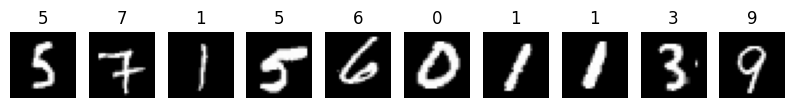

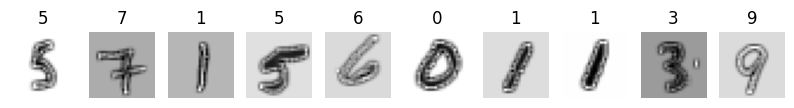

In [ ]:
#@title Applyig a kernel to an image and show before and after

from scipy.ndimage import convolve

# Define a 3x3 kernel

kernel = np.array([[ -1, -1,  -1],
                   [ -1,  4,  -1],
                   [ -1, -1,  -1]])

xs=[x]
ys=[1]
xs,ys = random_xys(10)
show(xs,ys)

xs = [convolve(x/255, kernel)*255 for x in xs]
show(xs,ys)



10 randomly selected images


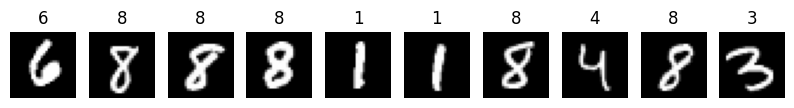

10 randomly selected images with pixel values divided by two


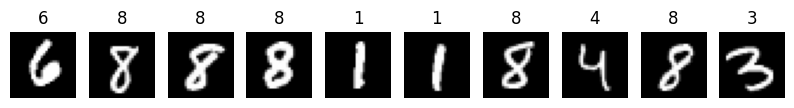


Pairwise distances for the above images
Euclidean distances:  [1346.09221452321, 1226.4809415559623, 1447.875253604398, 1526.7182942507764, 1030.5824809300807, 1006.3666081503301, 1293.2569350287667, 872.1072181790494, 1237.0050525361648, 1262.956848035593]
Cosine similarities:  [1.0000000000000002, 1.0000000000000002, 1.0, 1.0, 0.9999999999999998, 1.0, 1.0000000000000002, 1.0, 1.0, 0.9999999999999999]


10 most similar images to first digit by euclidean distance


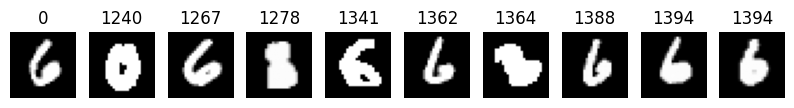

10 most similar images to first digit by cosine similarity


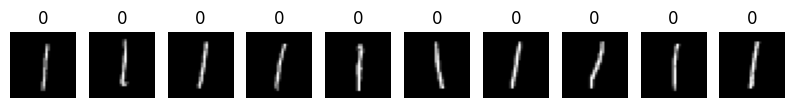

[9.01778888684191e-05, 8.836753602497228e-05, 8.444437766330968e-05, 8.199572311568062e-05, 7.844975796881886e-05, 7.661404237904467e-05, 7.602937667819313e-05, 7.561050657019344e-05, 7.504586340461032e-05, 7.462389581520864e-05]


In [ ]:
#@title Euclidean vs cosine similarity

xs,ys = random_xys(10)
print("10 randomly selected images")
show(xs,ys)

x2s = [x/2 for x in xs]
print("10 randomly selected images with pixel values divided by two")
show(x2s,ys)

print("\nPairwise distances for the above images")
print("Euclidean distances: ", [dist(x,x/2) for x in xs])
print("Cosine similarities: ", [cosine_similarity(x,x/2) for x in xs])

print("\n\n10 most similar images to first digit by euclidean distance")
xs_k_nn = list(sorted(x_train, key=lambda x:dist(xs[0],x)))[:10]

show(xs_k_nn, [int(dist(xs[0],x)) for x in xs_k_nn])

print("10 most similar images to first digit by cosine similarity")
xs_k_nn_cos = list(sorted(x_train, key=lambda x:cosine_similarity(xs[0],x),reverse=True))[:10]

show(xs_k_nn_cos, [cosine_similarity(xs[0],x) for x in xs_k_nn_cos])

print([cosine_similarity(xs[0],x) for x in xs_k_nn_cos])

# 2 Neuronal networks: Linear Regression

Linear regression tries to find weights $w_1$ and $w_0$ so that a function $w_1x+w_0$ approximates the given data best. It uses gradient descent to approach the best weights. Gradient descent is a principle used in many applications such as neural networks.

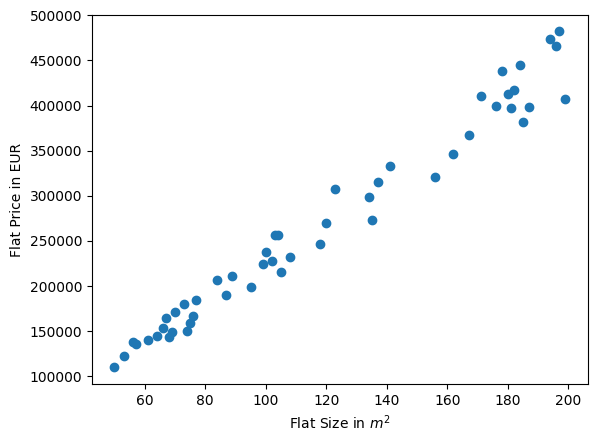

In [ ]:
#@title Linear regression. Generate data
import math, random
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

num = 50 #@param{type:"integer"}

sizes = random.sample(range(50, 200), num)
prices = [1000+size*(1000+offset) for (size,offset) in zip(sizes, random.sample(range(1000, 1500), num))]


plt.scatter(sizes, prices)
plt.ylabel("Flat Price in EUR")
plt.xlabel("Flat Size in $m^2$")
plt.show()


Initial setting: w1=0.00 w0=0.00
f(x)= 2193.59 x + 15.88


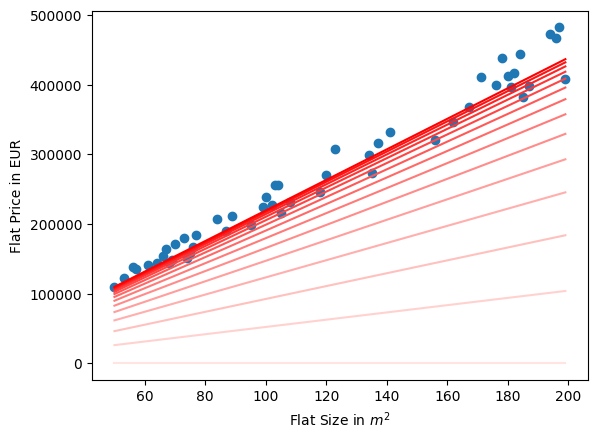

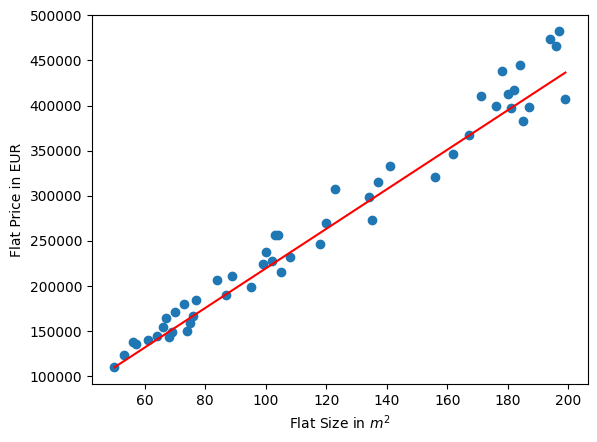

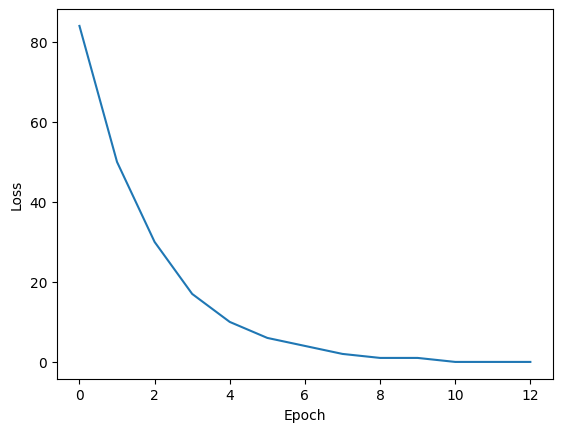

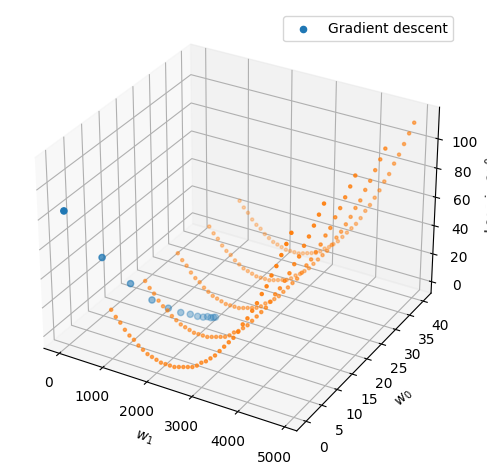

In [ ]:
#@title Linear regression. Gradient descent. Try alpha 0.00001

# learning rate
#alpha = 0.0001 #@param{type:"number"}
alpha = 0.000007 #@param {type:"slider", min:0.000001, max:0.0001, step:0.000001}

epochs = 13 #@param {type:"slider", min:3, max:100, step:1}

# intial weights. either randomly set or 0
random_w = False #@param{type:"boolean"}
if random_w:
  w0,w1=random.random()*50, random.random()*5000
else:
  w0,w1=0.0,0.0

def f(x):
  return w1*x + w0

def loss():
  return (1.0/num) * sum([math.pow(y-f(x), 2) for (x,y) in zip(sizes, prices)])

# Courtesy https://abhigupta.io/2022/07/23/gradient-in-matplotlib.html
def colorFader(c1,c2,mix=0): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    c1=np.array(mpl.colors.to_rgb(c1))
    c2=np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1-mix)*c1 + mix*c2)

#n = len(sizes)

print("Initial setting: w1=%.2f w0=%.2f"%(w1,w0))
x1,x2 = min(sizes), max(sizes)
l=[]
c1='mistyrose'
c2='red'
for i in range(epochs):
  # plot line for f(x) in gradient color from misty rose to red
  plt.plot([x1,x2], [f(x1),f(x2)], color=colorFader(c1,c2,i/epochs))  # regression line
  l.append((w0,w1,int(loss()/1000000000)))
  w0 += alpha*(2.0/num)*sum([  (y-f(x)) for (x,y) in zip(sizes, prices)])
  w1 += alpha*(2.0/num)*sum([x*(y-f(x)) for (x,y) in zip(sizes, prices)])

print("f(x)= %.2f x + %.2f"%(w1,w0))


plt.plot([x1,x2], [f(x1),f(x2)], color='red')  # regression line
plt.scatter(sizes, prices)
plt.ylabel("Flat Price in EUR")
plt.xlabel("Flat Size in $m^2$")
plt.show()

plt.plot([x1,x2], [f(x1),f(x2)], color='red')  # regression line
plt.scatter(sizes, prices)
plt.ylabel("Flat Price in EUR")
plt.xlabel("Flat Size in $m^2$")
plt.show()

plt.plot(range(epochs), [loss for (wo,w1,loss) in l])
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

l2=[]
for w0 in range(0,50,10): #50/10
  for w1 in range(1000,5000,100):
    l2.append([w0,w1,int(loss()/1000000000)])



fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
w0s,w1s,losss = zip(*l)
ax.scatter(w1s, w0s, losss, label="Gradient descent", marker="o")
w0s,w1s,losss = zip(*l2)
ax.scatter(w1s, w0s, losss,  marker=".")
ax.set_xlabel('$w_1$')
ax.set_ylabel('$w_0$')
ax.set_zlabel('Loss in $10^9$', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()


# 4 Neural network from scratch

We implement a neural network from scratch in Python

In [ ]:
#@title Basic classes and import of mnist

from keras.datasets import mnist
from keras import utils as keras_utils

from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np




class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward_propagation(self, input_data: np.ndarray) -> np.ndarray:
        raise NotImplementedError("Subklassen müssen diese Funktion implementieren! Die Layer-Klasse ist abstrakt.")

    def backward_propagation(self, output_error: np.ndarray, learning_rate: float) -> np.ndarray:
        raise NotImplementedError("Subklassen müssen diese Funktion implementieren! Die Layer-Klasse ist abstrakt.")


class FCLayer(Layer):

    def __init__(self, input_size: int, output_size: int):
        super().__init__()
        self.weights = np.random.rand(input_size, output_size) - 0.5
        self.bias = np.random.rand(1, output_size) - 0.5

    def forward_propagation(self, input_data: np.ndarray) -> np.ndarray:
        self.input = input_data
        self.output = np.dot(self.input, self.weights) + self.bias
        return self.output

    def backward_propagation(self, output_error: np.ndarray, learning_rate: float) -> np.ndarray:
        input_error = np.dot(output_error, self.weights.T)
        weights_error = np.dot(self.input.T, output_error)
        self.weights -= learning_rate * weights_error
        self.bias -= learning_rate * output_error
        return input_error

class ActivationLayer(Layer):
    def __init__(self, activation, activation_prime):
        super().__init__()
        self.activation = activation
        self.activation_prime = activation_prime

    def forward_propagation(self, input_data: np.ndarray) -> np.ndarray:
        self.input = input_data
        self.output = self.activation(self.input)
        return self.output

    def backward_propagation(self, output_error: np.ndarray, learning_rate: float) -> np.ndarray:
        return output_error * self.activation_prime(self.input)


def tanh(x: np.ndarray) -> np.ndarray:
    return np.tanh(x)

def tanh_prime(x: np.ndarray) -> np.ndarray:
    return 1 - np.tanh(x) ** 2


def relu(x: np.ndarray) -> np.ndarray:
    """Element-wise ReLU: max(0, x)"""
    return np.maximum(0, x)

def relu_prime(x: np.ndarray) -> np.ndarray:
    """Element-wise derivative of ReLU: 1 where x > 0, else 0"""
    return (x > 0).astype(x.dtype)



def mse(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    return np.mean(np.power(y_pred - y_true, 2))

def mse_prime(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    return 2 / y_true.size * (y_pred - y_true)


class Network:
    def __init__(self):
        self.layers = []
        self.loss = None
        self.loss_prime = None

    def add_layer(self, layer: Layer) -> None:
        self.layers.append(layer)

    def use_loss_function(self, loss, loss_prime) -> None:
        self.loss = loss
        self.loss_prime = loss_prime

    def predict(self, input_data: np.ndarray) -> np.ndarray:
        result = []
        for input_element in tqdm(input_data, desc='Prediction'):
            output = input_element
            for layer in self.layers:
                output = layer.forward_propagation(output)
            result.append(output)
        return np.array(result)

    def fit(self, x_train: np.ndarray, y_train: np.ndarray, epochs: int, learning_rate: float) -> None:
        for _ in (process_bar := tqdm(range(epochs), desc='Training')):
            epoch_error = 0
            for x_value, y_value in zip(x_train, y_train):
                output = x_value
                for layer in self.layers:
                    output = layer.forward_propagation(output)
                epoch_error += self.loss(y_value, output)
                propagated_error = self.loss_prime(y_value, output)
                for layer in reversed(self.layers):
                    propagated_error = layer.backward_propagation(propagated_error, learning_rate)
            epoch_error /= len(x_train)
            process_bar.set_postfix_str(f'Aktueller Fehler: {epoch_error}', refresh=False)

def reshape(x_data, y_data):
    x_data = x_data.reshape(x_data.shape[0], 1, 28 * 28)
    x_data = x_data.astype(np.float32)
    x_data /= 255
    y_data = keras_utils.to_categorical(y_data)
    return x_data, y_data


(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train2, y_train2 = reshape(x_train, y_train)
x_test2, y_test2 = reshape(x_test, y_test)




def show_with_label(fp):

  # Pick a random index in the fp
  n = 10
  fr = np.random.randint(0, len(fp)-n)
  fp10 = fp[fr:fr+n]

  plt.figure(figsize=(n, 1))        # plot n digits next to each other
  for i,(x,y,y_pred) in enumerate(fp10):
      plt.subplot(1, n, i+1)
      plt.axis('off')
      plt.imshow(x.reshape(28,28), cmap='gray')
      plt.title("%d/%d"%(y,y_pred))
  plt.show()




def max_val_index(array: np.ndarray) -> int:
    return max(enumerate(array), key=(lambda x: x[1]))[0]



def run_nn():
  out = net.predict(x_test2)

  nr_matches = sum([max_val_index(expected) == max_val_index(actual) for expected, [actual] in zip(y_test2, out)])
  accuracy = nr_matches / len(y_test2)
  print(f'Accuracy: {round(accuracy * 100, ndigits=2)}%')

  fp = [(x,max_val_index(y),max_val_index(y_pred)) for x,y, [y_pred] in zip(x_test2, y_test2, out) if max_val_index(y)!=max_val_index(y_pred)]
  show_with_label(fp)
  tp = [(x,max_val_index(y),max_val_index(y_pred)) for x,y, [y_pred] in zip(x_test2, y_test2, out) if max_val_index(y)==max_val_index(y_pred)]
  show_with_label(tp)



Prediction: 100%|██████████| 10000/10000 [00:00<00:00, 31239.77it/s]


Accuracy: 92.6%


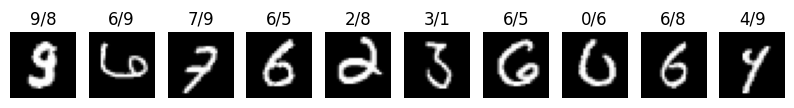

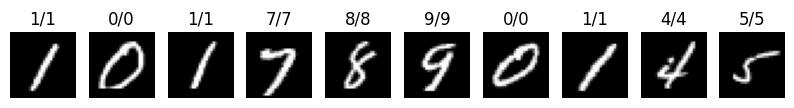

In [ ]:
#@title Define network

# 94.54% 60.000 samples, 10 epochs, 3 FC layers of size 100, tanh activation, mse loss, learning rate 0.1
# 92.6%  60.000 samples, 10 epochs, 2 FC layers of size 100, tanh activation, mse loss, learning rate 0.1

net = Network()
net.add_layer(FCLayer(28*28, 100))
net.add_layer(ActivationLayer(tanh, tanh_prime))
#net.add_layer(FCLayer(100, 100))
#net.add_layer(ActivationLayer(tanh, tanh_prime))
net.add_layer(FCLayer(100, 10))
net.add_layer(ActivationLayer(tanh, tanh_prime))

net.use_loss_function(mse, mse_prime)

nr_samples = 60000   # @param {type:"integer"}
epochs = 10         # @param {type:"integer"}
learning_rate = 0.1 # @param {type:"slider", min:0.1, max:1, step:0.1}

net.fit(x_train2[:nr_samples], y_train2[:nr_samples], epochs=epochs, learning_rate=learning_rate)
run_nn()


# 5 NN Tensorflow

We build a neural network for mnist in Python

In [ ]:
#@title mnist with TensorFlow
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)
x_train /= 255
x_test /= 255
x_train = x_train.reshape((x_train.shape[0], 28, 28, -1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, -1))
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
model = Sequential()
model.add(Input(shape=(28, 28, 1)))

#model.add(Dense(100, activation='tanh'))
#model.add(Dense(10, activation='tanh'))
#model.add(Dense(1, activation='tanh'))
#model.add(Dense(10, activation="softmax"))

model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))
model.summary()
#model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.compile(loss="mse", metrics=["accuracy"])
nr_samples = 100 # @param {"type":"integer","placeholder":"Größe der Trainingsdaten"}
model.fit(x_train[nr_samples:], y_train[nr_samples:], batch_size=64, epochs=10, validation_data=(x_test, y_test))


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
936/936 ━━━━━━━━━━━━━━━━━━━━ 91s 96ms/step - accuracy: 0.7881 - loss: 0.0286 - val_accuracy: 0.9712 - val_loss: 0.0042
Epoch 2/10
936/936 ━━━━━━━━━━━━━━━━━━━━ 91s 97ms/step - accuracy: 0.9615 - loss: 0.0059 - val_accuracy: 0.9815 - val_loss: 0.0027
Epoch 3/10
936/936 ━━━━━━━━━━━━━━━━━━━━ 89s 95ms/step - accuracy: 0.9722 - loss: 0.0044 - val_accuracy: 0.9864 - val_loss: 0.0021
Epoch 4/10
936/936 ━━━━━━━━━━━━━━━━━━━━ 143s 97ms/step - accuracy: 0.9778 - loss: 0.0034 - val_accuracy: 0.9879 - val_loss: 0.0019
Epoch 5/10
936/936 ━━━━━━━━━━━━━━━━━━━━ 91s 97ms/step - accuracy: 0.9795 - loss: 0.0032 - val_accuracy: 0.9873 - val_loss: 0.0019
Epoch 6/10
936/936 ━━━━━━━━━━━━━━━━━━━━ 143s 99ms/step - accuracy: 0.9824 - loss: 0.0028 - val_accuracy: 0.9891 - val_loss: 0.0017
Epoch 7/10
936/936 ━━━━━━━━━━━━━━━━━━━━ 141s 98ms/step - accuracy: 0.9856 - loss: 0.0023 - val_accuracy: 0.9885 - val_loss: 0.0017
Epoch 8/10
936/936 ━━━━━━━━━━━━━━━━━━━━ 92s 98ms/step - accuracy: 0.9867 - loss: 0.0021

In [ ]:
y_predicted = np.argmax(model.predict(x_test), axis=-1)

# forme y_test von One-Hot in Zahlenform um
y_true = np.argmax(y_test, axis=-1)

# sammele alle falschen predictions
wrong_predictions = [tup for tup in list(zip(x_test, y_true, y_predicted)) if tup[1] != tup[2]]

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


In [ ]:
show_misclassified(wrong_predictions)

NameError: name 'wrong_predictions' is not defined

# 6 Decision tree

In [ ]:
#@title Prepare data

data = [
["NearbyAlternative",  "Bar",  "Friday/Saturday",  "Hungry",  "Patrons",   "Price",  "Rain",  "Reservation",  "Type",     "Estimated Wait",    "Wait"],
#"Alt",  "Bar",  "Fri",  "Hun",  "Pat",   "Price",  "Rain",  "Res",  "Type",     "Est",    "Wait"],
["Yes",  "No",   "No",   "Yes",  "Some",  "$$$",    "No",    "Yes",  "French",   "0-10",   "Yes"],
["Yes",  "No",   "No",   "Yes",  "Full",  "$",      "No",    "No",   "Thai",     "30-60",  "No"],
["No",   "Yes",  "No",   "No",   "Some",  "$",      "No",    "No",   "Burger",   "0-10",   "Yes"],
["Yes",  "No",   "Yes",  "Yes",  "Full",  "$",      "No",    "No",   "Thai",     "10-30",  "Yes"],
["Yes",  "No",   "Yes",  "No",   "Full",  "$$$",    "No",    "Yes",  "French",   ">60",    "No"],
["No",   "Yes",  "No",   "Yes",  "Some",  "$$",     "Yes",   "Yes",  "Italian",  "0-10",   "Yes"],
["No",   "Yes",  "No",   "No",   "None",  "$",      "Yes",   "No",   "Burger",   "0-10",   "No"],
["No",   "No",   "No",   "Yes",  "Some",  "$$",     "Yes",   "Yes",  "Thai",     "0-10",   "Yes"],
["No",   "Yes",  "Yes",  "No",   "Full",  "$",      "Yes",   "No",   "Burger",   ">60",    "No"],
["Yes",  "Yes",  "Yes",  "Yes",  "Full",  "$$$",    "No",    "Yes",  "Italian",  "10-30",  "No"],
["No",   "No",   "No",   "No",   "None",  "$",      "No",    "No",   "Thai",     "0-10",   "No"],
["Yes",  "Yes",  "Yes",  "Yes",  "Full",  "$",      "No",    "No",   "Burger",   "30-60",  "Yes"]
]

header = data[0] # header from data
data = data[1:]      # remove header from data


In [ ]:
#@title Decision tree
from collections import defaultdict
from math import log
import random

verbose = True #@param {type:"boolean"}
bootstrapping = False #@param {type:"boolean"}



def entropy(labels):
  probabilities = [labels.count(label) / len(labels) for label in set(labels)]
  return -sum([probability*log(probability,2) for probability in probabilities])

def information_gain(examples, attribute):
  labels = [data[example][-1] for example in examples] # data[example][-1] is the label of example
  values = set([data[example][attribute] for example in examples]) # all values for a given attribute
  value2labels = defaultdict(list)
  for example in examples:
    value2labels[data[example][attribute]].append(data[example][-1])
  return entropy(labels) - sum([len(labels_i) / len(labels) * entropy(labels_i) for labels_i in value2labels.values()])

def separate(examples, attribute):
  values = set([data[example][attribute] for example in examples])
  pairs = [(data[example][attribute], example) for example in examples]
  value2examples = defaultdict(list)
  for (value, index) in pairs:
    value2examples[value].append(index)
  return value2examples

def question(examples, indent):
  if entropy([data[example][-1] for example in examples]) == 0.0:
    print(" "*indent + header[-1]+"="+data[examples[0]][-1])
  else:
    attributes = range(len(header)-1)
    best = max(attributes, key=lambda attribute: information_gain(examples, attribute))
    if verbose:
      s=", ".join(["%s %.2f"%(header[attribute][:3], information_gain(examples, attribute)) for attribute in sorted(attributes, key=lambda attribute: information_gain(examples, attribute), reverse=True)])
      print(" "*indent + "Information gain:")
      print(" "*indent + s)
    value2examples = separate(examples, best)
    for (value, examples4value) in value2examples.items():
      print(" "*indent + "if "+header[best]+"=="+value+":")
      question(examples4value, indent+3)

examples = range(len(data))

print("Overal there are %d examples."%len(data))

if not bootstrapping:
  question(examples, 0)
else:
  for bootstrap in range(3):
    subset = random.choices(examples,k=int(1.0*len(examples)))
    print()
    print("Decision tree for examples ", sorted(subset))
    question(subset,0)


Overal there are 12 examples.
Information gain:
Pat 0.54, Est 0.21, Hun 0.20, Pri 0.20, Fri 0.02, Res 0.02, Typ 0.00, Nea 0.00, Bar 0.00, Rai 0.00
if Patrons==Some:
   Wait=Yes
if Patrons==Full:
   Information gain:
   Hun 0.25, Pri 0.25, Res 0.25, Typ 0.25, Est 0.25, Nea 0.11, Fri 0.11, Rai 0.11, Bar 0.00, Pat 0.00
   if Hungry==Yes:
      Information gain:
      Typ 0.50, Fri 0.31, Pri 0.31, Res 0.31, Nea 0.00, Bar 0.00, Hun 0.00, Pat 0.00, Rai 0.00, Est 0.00
      if Type==Thai:
         Information gain:
         Fri 1.00, Est 1.00, Nea 0.00, Bar 0.00, Hun 0.00, Pat 0.00, Pri 0.00, Rai 0.00, Res 0.00, Typ 0.00
         if Friday/Saturday==No:
            Wait=No
         if Friday/Saturday==Yes:
            Wait=Yes
      if Type==Italian:
         Wait=No
      if Type==Burger:
         Wait=Yes
   if Hungry==No:
      Wait=No
if Patrons==None:
   Wait=No


In [ ]:
#@title Entropy on mnist

from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from math import log


# load mnist data separated into images (x) and labels (y)
# and separated into training and test data

(x_train, y_train), (x_test, y_test) = mnist.load_data()

white_threshold = 10 #@param {type:"number"}

def entropy(labels):
  probabilities = [list(labels).count(label) / len(labels) for label in set(labels)]
  return -sum([probability*log(probability,10) for probability in probabilities])

entropies=[]
for i in tqdm(range(28)):
  for j in range(28):
    # ndarray with 60000 values for poistion i,j
    pixel_values = x_train[:, i, j]
    # labels of those pixels in above list, which are above threshold (0 black, 255 white)
    labels = [y_train[index] for index in range(len(y_train)) if pixel_values[index]>white_threshold]
    entropies.append((entropy(labels), len(labels)))



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


100%|██████████| 28/28 [01:59<00:00,  4.27s/it]


462 out of 784 pixels are white in at least 1000 images


Text(0.5, 0, 'Entropy')

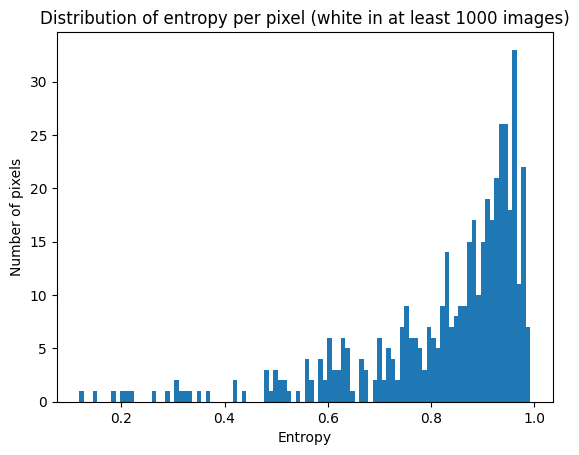

In [ ]:
#@title Histogram of mnist pixel entroies
# plot entropies for all pixels which are white (above white_threshold) for at least min_images
min_images=1000
filtered_entropies = [entropy for entropy,length in entropies if length>min_images]
print("%d out of 784 pixels are white in at least %d images"%(len(filtered_entropies), min_images))
plt.hist(filtered_entropies, bins=100)
plt.title("Distribution of entropy per pixel (white in at least %d images)"%min_images)
plt.ylabel('Number of pixels')
plt.xlabel('Entropy')

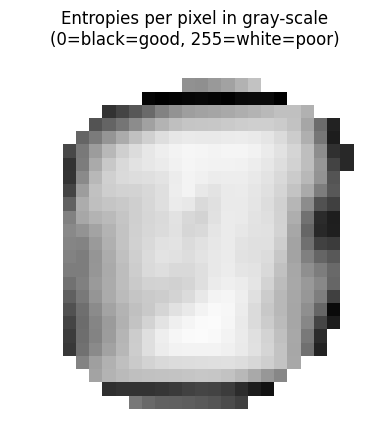

In [ ]:
#@title Gray-scale image of mnist entropies

def entropy_to_gray(entropy, length):
  if length < min_images:
    return 255
  return int(255*2*abs(0.5-entropy))


x = np.array([entropy_to_gray(entropy, length) for entropy, length in entropies])
#plt.figure(figsize=(1, 1))
plt.axis('off')
plt.title("Entropies per pixel in gray-scale\n(0=black=good, 255=white=poor)")
plt.imshow(x.reshape(28,28), cmap='gray')
plt.show()


In [ ]:
#@title Histogram accuracy vs decision tree depth for mnist

from keras.datasets import mnist
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import export_text

max_max_depth = 2 #@param {type:"integer"}

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

def acc(y_test,y_pred):
  return sum([i==j for i,j in zip(y_test,y_pred)])/len(y_test)

accuracies = []
for max_depth in range(1, max_max_depth+1):
    clf = RandomForestClassifier(max_depth=max_depth)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    accuracies.append(accuracy_score(y_test, y_pred))
    print(f"Max Depth: {max_depth}, Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    if max_depth < 4:
      print(acc(y_test,y_pred))
      print(set(y_pred))
      print(len(clf.estimators_))
      #print(export_text(clf.estimators_[0]))

plt.plot(range(1, max_max_depth), accuracies)
plt.title('Random forest for mnist\nAccuracy vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.show()

Max Depth: 1, Accuracy: 0.5295
0.5295
{0, 1, 2, 3, 4, 6, 7, 8, 9}
100
Max Depth: 2, Accuracy: 0.6569
0.6569
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
100


NameError: name 'plt' is not defined

In [ ]:
#@title Number of features used in the final decision tree

features_used = set()
for tree in clf.estimators_:
    features_used.update(tree.tree_.feature[tree.tree_.feature >= 0])

print(len(features_used))








593


In [ ]:
from keras.datasets import mnist
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import export_text

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

clf = RandomForestClassifier()
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(export_text(clf.estimators_[0]))


Accuracy: 0.9709
|--- feature_346 <= 0.50
|   |--- feature_262 <= 0.50
|   |   |--- feature_511 <= 2.50
|   |   |   |--- feature_406 <= 246.50
|   |   |   |   |--- feature_155 <= 2.50
|   |   |   |   |   |--- feature_436 <= 44.50
|   |   |   |   |   |   |--- feature_204 <= 1.50
|   |   |   |   |   |   |   |--- feature_275 <= 7.50
|   |   |   |   |   |   |   |   |--- feature_565 <= 13.50
|   |   |   |   |   |   |   |   |   |--- feature_521 <= 2.50
|   |   |   |   |   |   |   |   |   |   |--- feature_685 <= 51.00
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |   |   |   |   |   |   |   |--- feature_685 >  51.00
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |--- feature_521 >  2.50
|   |   |   |   |   |   |   |   |   |   |--- feature_130 <= 66.00
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |   |   |   |   |   |   |--- feature_130 >

Text(0, 0.5, 'f(x)')

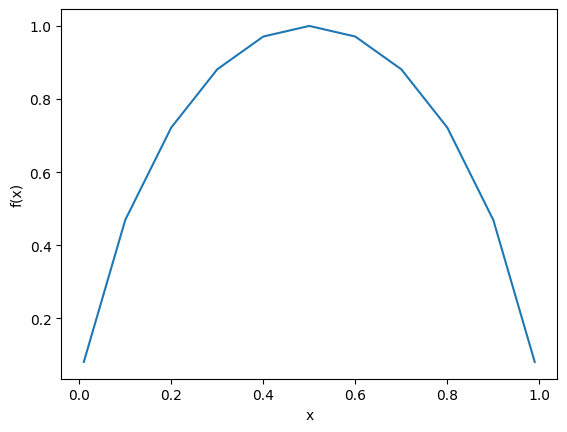

In [ ]:
#@title Plot entropy

from math import log

import matplotlib.pyplot as plt

def f(x):
  return -x*log(x,2) - (1-x)*log(1-x,2)

# plot f(x)
x = [0.01,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
y = [f(i) for i in x]
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('f(x)')


# 7 Probabilisitc reasoning

We implement a simple spam filter

Execute wget and unzip to retrieve the data from UC Irvine Machine Learning Repository.

In [ ]:
#@title Load spam/ham messages

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
!unzip smsspamcollection.zip

--2025-01-18 13:43:00--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip’

smsspamcollection.z     [ <=>                ] 198.65K  --.-KB/s    in 0.1s    

2025-01-18 13:43:00 (1.47 MB/s) - ‘smsspamcollection.zip’ saved [203415]

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


Here is the main piece of code, which computes probabilities from the training data and uses it in the predict function for the test data. The third part of the code computes accuracy measures for the prediction.

In [ ]:
#@title Bayes

from collections import defaultdict
from tabulate import tabulate
import random

data = [line.split("\t") for line in open("SMSSpamCollection")]
random.shuffle(data)
upto = int(len(data)*0.8)
training_data, test_data = data[:upto], data[upto:]

labels = [label for (label,msg) in training_data]
sum_n_ham  = labels.count("ham")
sum_n_spam = labels.count("spam")
p_ham  = sum_n_ham  / len(labels)
p_spam = sum_n_spam / len(labels)

def msg2words2(msg):
  return set(msg.split())

n_ham, n_spam = defaultdict(int), defaultdict(int)
for [label, msg] in training_data:
  for word in msg2words2(msg):
    if label=="ham":
      n_ham[word] += 1
    else:
      n_spam[word] += 1

n_voc = len(set(list(n_ham.keys())+list(n_spam.keys())))

def predict(msg):
  p_msg_ham = 1.0
  p_msg_spam = 1.0
  for word in msg2words2(msg):
    p_msg_ham  *= (n_ham[word] +1) / (sum_n_ham +n_voc+2)
    p_msg_spam *= (n_spam[word]+1) / (sum_n_spam+n_voc+2)
  if p_msg_ham*p_ham >= p_msg_spam*p_spam:
    return "ham"
  return "spam"

fn,tp,fp,tn = 0.0,0.0,0.0,0.0
for [label, msg] in test_data:
  predicted = predict(msg)
  if   label == "spam" and predicted == "spam": tp += 1
  elif label == "ham"  and predicted == "ham":  tn += 1
  elif label == "spam" and predicted == "ham":  fn += 1
  elif label == "ham"  and predicted == "spam": fp += 1
precision = tp / (tp+fp)
recall = tp / (tp+fn)
accuracy = (tp+tn) / (tp+fp+tn+fn)

print("There are %d messages. %d (%d%%) ham and %d (%d%%) spam SMS."%(sum_n_ham+sum_n_spam,sum_n_ham,int(100*p_ham),sum_n_spam, int(100*p_spam)))
print("Precision is %.2f, recall %.2f, accuracy %.2f."%(precision,recall,accuracy))

There are 4459 messages. 3856 (86%) ham and 603 (13%) spam SMS.
Precision is 1.00, recall 0.67, accuracy 0.96.


Let's try to understand the data better. We print 10 randomly selected example messages.

In [ ]:
# print 10 random messages

from tabulate import tabulate
import random

examples = []
for row in random.sample(data,10):
  examples.append(row)
print("\n10 randomly selected example messages:")
print(tabulate(examples))


10 randomly selected example messages:
----  ----------------------------------------------------------------------------------------------------------------------------------------------------
ham   Tiwary to rcb.battle between bang and kochi.
ham   Hows the pain dear?y r u smiling?
spam  HOT LIVE FANTASIES call now 08707500020 Just 20p per min NTT Ltd, PO Box 1327 Croydon CR9 5WB 0870 is a national rate call
ham   Well i know Z will take care of me. So no worries.
ham   Shb b ok lor... Thanx...
spam  Sorry! U can not unsubscribe yet. THE MOB offer package has a min term of 54 weeks> pls resubmit request after expiry. Reply THEMOB HELP 4 more info
ham   Moji i love you more than words. Have a rich day
ham   I think just yourself …Thanks and see you tomo
ham   Draw va?i dont think so:)
ham   Did you catch the bus ? Are you frying an egg ? Did you make a tea? Are you eating your mom's left over dinner ? Do you feel my Love ?
----  -------------------------------------------------------

In [ ]:
# count frequent messages

from collections import defaultdict

d=defaultdict(int)

for [label, msg] in data:
  d[(label,msg)]+=1
for ((label,msg),freq) in sorted(d.items(), key=lambda x:x[1], reverse=True)[:20]:
  print(freq, label,msg.strip())



30 ham Sorry, I'll call later
12 ham I cant pick the phone right now. Pls send a message
10 ham Ok...
4 spam Please call our customer service representative on FREEPHONE 0808 145 4742 between 9am-11pm as you have WON a guaranteed £1000 cash or £5000 prize!
4 ham Wen ur lovable bcums angry wid u, dnt take it seriously.. Coz being angry is d most childish n true way of showing deep affection, care n luv!.. kettoda manda... Have nice day da.
4 ham Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART WITH YOUR BLOOD.Send this to Ten special people &amp; u c miracle tomorrow, do it,pls,pls do it...
4 ham 7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS and 1st "Ur Lovely Friendship"... good morning dear
4 ham Ok.
4 ham Ok
4 ham Okie
4 ham Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9. Simple Pls reply..
3 ham Gud mrng dear hav a nice day
3 ham Fighting with t

In [ ]:
from tabulate import tabulate
import random

n=1
long_msg=True
examples = []
for row in list(sorted(data, key=lambda x: len(x[1]), reverse=long_msg))[:n]:
  examples.append(row)
print("\nMessages sorted by length:")
print(tabulate(examples))


Messages sorted by length:
---  ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ham  For me the love should start with attraction.i shou

Text(0.5, 0, 'Message length')

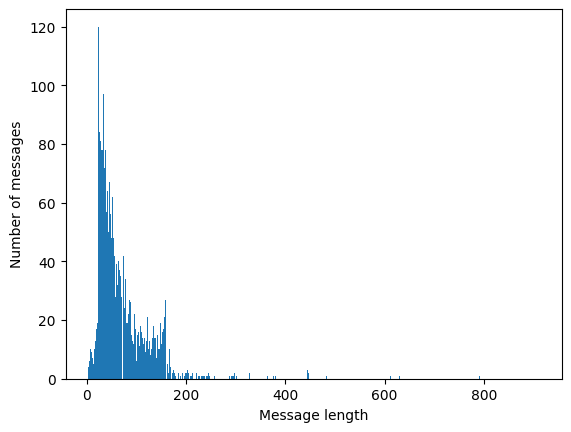

In [ ]:
# plot the length distribution of message in data

from collections import defaultdict
import matplotlib.pyplot as plt


def condition(label,msg):
  return label=="ham"

lengths = [len(msg) for [label, msg] in data if condition(label,msg)]

plt.hist(lengths, bins=1000)
plt.ylabel('Number of messages')
plt.xlabel('Message length')



Let's try to understand the data better. Which words appear frequently in ham and spam messages. Do these words overlap or are there clearly distinct words.

In [ ]:
print(n_ham["Congratulations"])

1


In [ ]:
print("Frequent ham words:  ", end="")
for (word,freq) in sorted(n_ham.items(), key=lambda x:x[1], reverse=True)[:20]:
  print(word, end="|")

print()
print("Frequent spam words: ", end="")
for (word,freq) in sorted(n_spam.items(), key=lambda x:x[1], reverse=True)[:20]:
  print(word, end="|")

print()
spam_only = set(n_spam.keys()) - set(n_ham.keys())
print("Words only in spam: %d"%(len(spam_only)))
print("Frequent words only in spam: ", end="")
for word in sorted(spam_only, key=lambda x:n_spam[x], reverse=True)[:20]:
  print(word, end="|")

print()
ham_only = set(n_ham.keys()) - set(n_spam.keys())
print("Words only in ham: %d"%(len(spam_only)))
print("Frequent words only in ham: ", end="")
for word in sorted(ham_only, key=lambda x:n_ham[x], reverse=True)[:20]:
  print(word, end="|")


print()
common = set(n_ham.keys()).intersection(set(n_spam.keys()))
print("Spam has %d words and ham %d. They have %d words in common."%(len(n_ham.keys()), len(n_spam.keys()), len(common)))
print("Frequent words common to both: ", end="")
for word in sorted(common, key=lambda x:n_spam[x]+n_ham[x], reverse=True)[:20]:
  print(word, end="|")


Frequent ham words:  to|you|I|a|the|in|and|i|is|my|me|u|of|for|that|it|your|on|not|have|
Frequent spam words: to|a|or|call|your|the|for|you|Call|is|have|2|from|on|and|with|of|our|ur|You|
Words only in spam: 2070
Frequent words only in spam: WON|T&C|representative|wkly|S.|M.|I.|word:|Bluetooth|Del|custcare|Sol|Costa|3030.|FREE.|Max10mins|Camera!|Digital|TnCs|SAE,|
Words only in ham: 2070
Frequent words only in ham: That's|Ya|change|back.|her.|second|worry|seeing|swing|Wish|crave|through|Nothing|here,|*grins*|soon.|life.|fine,|SO|gave|
Spam has 13663 words and ham 7833. They have 5763 words in common.
Frequent words common to both: to|you|I|a|the|in|and|is|i|for|my|of|u|me|your|have|on|that|are|or|

Let's try to understand the data better. The lecture mentioned the Zipf law originally observed in the 60s in word frequencies of file and directory names. Does it apply to SMS messages, too? A plot will give us the positive answer.

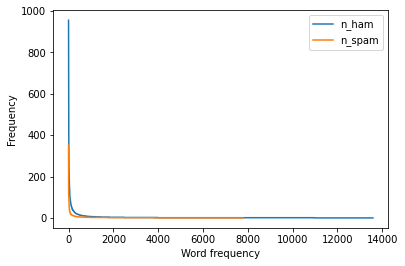

In [ ]:
import matplotlib.pyplot as plt
plt.plot(sorted(n_ham.values(), reverse=True)[0:], label="n_ham")
plt.plot(sorted(n_spam.values(), reverse=True)[0:], label="n_spam")
plt.ylabel('Frequency')
plt.xlabel('Word frequency')
plt.legend()
plt.show()

Let's try to understand the data better. Let's look at misclassified examples and whether each message's words individually. Are they pointing to ham or spam? Why did the classifier get it wrong?

In [ ]:
def print_example(label,predicted,msg):
  table=[["word","ham", "", "spam"]]
  for word in msg2words(msg):
    p_w_ham  = (n_ham[word] +1) / (sum_n_ham +n_voc)
    p_w_spam = (n_spam[word]+1) / (sum_n_spam+n_voc)
    if p_w_ham > p_w_spam:
      greater = ">"
    else:
      greater = "<="
    table.append([word, p_w_ham, greater, p_w_spam])
  print()
  print("%s was predicted %s"%(label, predicted))
  print(tabulate(table))

for [label, msg] in test_data:
  predicted = predict(msg)
  if label == "spam" and predicted == "ham":
    print_example(label,predicted,msg)
  elif label == "ham"  and predicted == "spam":
    print_example(label,predicted,msg)




We assume that words are independent of each other. Is this valid? For most pairs it will be, but for some it won't.

In [ ]:
cooc = defaultdict(int)

for [label, msg] in data:
  words = msg.split()
  for i in range(len(words)-1):
    cooc[(words[i], words[i+1])] += 1

table = [[w1,w2,cooc[(w1,w2)]] for ((w1,w2),v) in sorted(cooc.items(), key=lambda x:x[1], reverse=True)[0:10]]
print(tabulate(table))


----  ---  --
I     am   88
in    the  86
are   you  81
have  a    80
want  to   77
to    be   77
will  be   76
in    a    74
.     .    73
you   are  70
----  ---  --


Let's judge the dependency of word consecutive words differently. Instead of counting absolute frequency, let's compute relative frequencies with the log odds ratio.

In [ ]:
freq = defaultdict(int)
logodds = defaultdict(float)
for [label, msg] in data:
  words = msg.split()
  for word in words:
    freq[word] += 1

for (w1,w2) in cooc:
  if freq[w1]>100 and freq[w2]>100:
    logodds[(w1,w2)] = cooc[(w1,w2)] / (freq[w1] * freq[w2])

table = [[w1,w2,logodds[(w1,w2)]] for ((w1,w2),v) in sorted(logodds.items(), key=lambda x:x[1], reverse=True)[:10]]
print(tabulate(table))

---------  -----  -----------
has        been   0.00217486
.          .      0.00125687
I'll       call   0.000828708
don't      know   0.000711125
I'll       text   0.00063262
day        ?      0.000629129
will       be     0.000628728
don't      think  0.000626517
&lt;#&gt;  .      0.000616393
no         need   0.000567924
---------  -----  -----------


How many examples are there and how many distinct words.

In [ ]:
print("%d examples and %d distinct words"%(len(data),len(freq)))

5574 examples and 15733 distinct words


Which are the most frequent words and how is frequency independently of ham or spam distributed.

Frequent words: to, you, I, a, the, and, in, is, i, u, for, my, of, me, your, on, have, 2, that, are, it, call, or, be, at, with, not, will, get, can, U, ur, so, I'm, but, &lt;#&gt;, You, from, 4, up, do, ., if, just, go, when, like, know, this, we, all, out, got, was, come, now, ?, am, ..., want, by, Call, time, send, about, only, then, what, need, going, n, I'll, How, still, as, If, one, But, its, he, text, No, our, no, been, Just, We, there, So, love, see, has, some, good, r, Do, think, don't, how, any, &, back, an, home, ü, Your, tell, day, take, My, What, her, dont, free, And, me., Ok, A, The, d, mobile, who, they, i'm, make, FREE, give, him, new, -, phone, later, more, now., she, &amp;, much, Have, you., ask, To, Are, This, Hey, had, great, way, txt, should, Can, reply, here, claim, Good, say, da, meet, e, Its, after, too, really, them, number, very, week, lor., contact, Txt, would, said, every, 1, find, pick, Please, doing, miss, night, work, Pls, did, sent, stop, Oh, right, ok,

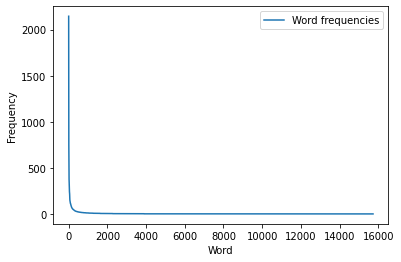

In [ ]:
freq_words = [k for (k,v) in sorted(freq.items(), key=lambda x:x[1], reverse=True)]
print("Frequent words: %s"%(", ".join(freq_words)))


plt.plot(sorted(freq.values(), reverse=True)[0:], label="Word frequencies")
plt.ylabel('Frequency')
plt.xlabel('Word')
plt.legend()
plt.show()

Let's put it together and remove stop words and run the original code and classification again. Run the code below to implement an improved msg2words function. Then go to first piece of code with the Bayes classifier. Comment out the old function msg2words function and run the Bayes classifier code again and voila you have implemented a really good spam filter.

Besides the basic idea of using the Bayes rule, implementing Laplace smooting and removing stopwords leads to very good overall classification results. Amazing, that such a few lines of code can deliver so good results for a task that would drive us crazy if we had to do it manually.

In [ ]:
stopwords = freq_words[:100]

def clean(w):
  return w.replace('\W+', ' ').replace('\s+', ' ').lower().strip()

def msg2words(msg):
  return set([clean(word) for word in msg.split() if word not in stopwords])

NameError: ignored

In [ ]:
# Download Harry Potter 1 as .txt
!wget -O hp.txt raw.githubusercontent.com/amephraim/nlp/refs/heads/master/texts/J.%20K.%20Rowling%20-%20Harry%20Potter%201%20-%20Sorcerer\'s%20Stone.txt

--2024-12-18 17:44:47--  http://raw.githubusercontent.com/amephraim/nlp/refs/heads/master/texts/J.%20K.%20Rowling%20-%20Harry%20Potter%201%20-%20Sorcerer's%20Stone.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/amephraim/nlp/refs/heads/master/texts/J.%20K.%20Rowling%20-%20Harry%20Potter%201%20-%20Sorcerer's%20Stone.txt [following]
--2024-12-18 17:44:47--  https://raw.githubusercontent.com/amephraim/nlp/refs/heads/master/texts/J.%20K.%20Rowling%20-%20Harry%20Potter%201%20-%20Sorcerer's%20Stone.txt
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 439742 (429K) [text/plain]
Saving to: ‘hp.txt’

hp.tx

In [ ]:
!ls

bpe_model.model  hp.txt  sample_data	    smsspamcollection.zip
bpe_model.vocab  readme  SMSSpamCollection


In [ ]:
#@title Generate byte pair encoding for spam/ham data (requires data file SMSSpamCollection)

import sentencepiece as spm


# Train a BPE model with SentencePiece
text_file = "SMSSpamCollection"
#text_file = "hp.txt"
spm.SentencePieceTrainer.train(input="SMSSpamCollection", model_prefix="bpe_model", vocab_size=32000, model_type="bpe")

# Load the trained model
sp = spm.SentencePieceProcessor(model_file="bpe_model.model")

# Encode a sample string
encoded = sp.encode("this is a sample", out_type=str)
print("Encoded:", encoded)

# Decode back to string
decoded = sp.decode(encoded)
print("Decoded:", decoded)


Encoded: ['▁this', '▁is', '▁a', '▁s', 'amp', 'le']
Decoded: this is a sample


In [ ]:
s="""
cats catlike catty
fishing fished fisher
argue argued argues arguing argus
universal university universe
"""

for line in s.strip().split("\n"):
  encoded = sp.encode(line, out_type=str)
  print(encoded)


['▁cat', 's', '▁cat', 'like', '▁cat', 'ty']
['▁fish', 'ing', '▁f', 'ished', '▁fis', 'her']
['▁argue', '▁arg', 'ued', '▁arg', 'ues', '▁arguing', '▁arg', 'us']
['▁uni', 'vers', 'al', '▁university', '▁uni', 'verse']


In [ ]:
#@title Vocabulary learned by BPE

import sentencepiece as spm
import statistics

# Load the trained BPE model
sp = spm.SentencePieceProcessor(model_file="bpe_model.model")

# Print the actual tokens it learned along with their frequencies
vocab_size = sp.get_piece_size()


def print_stats(s,values):
  m = statistics.mean(values)
  m2 = int(statistics.median(values))
  m3 = int(min(values))
  m4 = int(max(values))
  std = statistics.stdev(values)
  print("%s min: %d max: %d median: %d mean: %.2f, std: %.2f"%(s,m3,m4,m2,m,std))

n=20

print_stats("Scores:", [sp.get_score(i) for i in range(vocab_size)])
sorted_scores = sorted(range(vocab_size), key=lambda i: sp.get_score(i))
bot_scores = [sp.id_to_piece(i) for i in list(sorted_scores)[:n]]
top_scores = [sp.id_to_piece(i) for i in list(sorted_scores)[-n:]]
print("Best %d: "%n+" ".join(top_scores))
print("Worst %d: "%n+" ".join(bot_scores))

print_stats("Lengths:", [len(sp.id_to_piece(i)) for i in range(vocab_size)])
sorted_len = sorted(range(vocab_size), key=lambda i: len(sp.id_to_piece(i)))
top_len = [sp.id_to_piece(i) for i in list(sorted_len)[:n]]
bot_len = [sp.id_to_piece(i) for i in list(sorted_len)[-n:]]
print("Shortest %d: "%n+" ".join(top_len))
print("Longest %d: "%n+" ".join(bot_len))



Scores: min: -1196 max: 0 median: -596 mean: -596.50, std: 346.55
Best 20: ll ▁i he ▁c .. on ▁m re ▁w ou ▁ham ▁s ▁a in am ▁h <unk> <s> </s> ▁t
Worst 20: ‘ @  = Ü Q ( ü + q # J * X £ " V K / z
Lengths: min: 1 max: 10 median: 3 mean: 3.44, std: 1.58
Shortest 20: ▁ e a o t n i s h r m l . u d y c g w p
Longest 20: ▁tonight ▁collect ▁service ▁someone ▁special ▁getting ▁friends ▁waiting ▁thought ▁meeting ▁receive ▁weekend ▁problem ▁awarded ▁another ▁because ▁tomorrow ▁anything ▁customer ▁something


In [ ]:
#@title Compression ratio (size after/size before) for BPE

import sentencepiece as spm

# Load the SentencePiece model
sp = spm.SentencePieceProcessor(model_file="bpe_model.model")

# Original text
total_msg = " ".join([msg for [label,msg] in data])

# Encode text
encoded = sp.encode(total_msg, out_type=str)

# Calculate lengths
original_length = len(total_msg)
encoded_length = len(encoded)

# Compute compression ratio
compression_ratio = encoded_length / original_length
print(f"Original Length: {original_length}")
print(f"Encoded Length: {encoded_length}")
print(f"Compression Ratio: {compression_ratio}")


Original Length: 459733
Encoded Length: 171514
Compression Ratio: 0.37307306632327897


100%|██████████| 7/7 [00:11<00:00,  1.63s/it]


[0.8857641283092578, 0.6138280262674204, 0.49306662780352944, 0.44207833677373604, 0.4110538073185958, 0.3893564307978762, 0.37307306632327897]


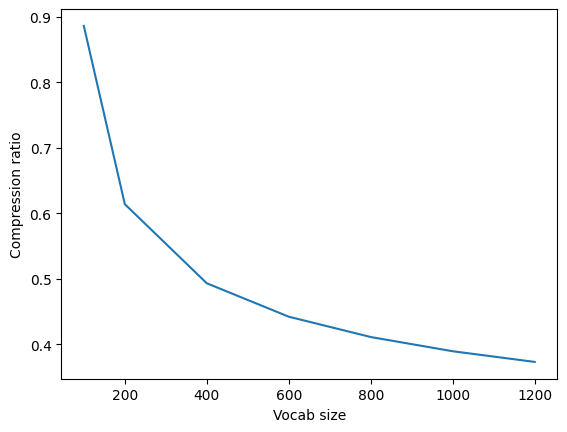

In [ ]:
#@title Comrpession ratio (size after/size before) dependent on size of vocabulary of BPE

from matplotlib import pyplot as plt
import sentencepiece as spm
from tqdm import tqdm



total_msg = " ".join([msg for [label,msg] in data])
original_length = len(total_msg)
x = [100,200,400, 600, 800, 1000, 1200]
y = []
for size in tqdm(x):
  spm.SentencePieceTrainer.train(input="SMSSpamCollection", model_prefix="bpe_model", vocab_size=size, model_type="bpe")
  sp = spm.SentencePieceProcessor(model_file="bpe_model.model")
  encoded = sp.encode(total_msg, out_type=str)
  encoded_length = len(encoded)
  compression_ratio = encoded_length / original_length
  y.append(compression_ratio)
print(y)
plt.plot(x,y)
plt.xlabel('Vocab size')
plt.ylabel('Compression ratio')
plt.show()


# 8 Unsupervised learning

K means iteratively assigns data points to the nearest representative. After completing a cycle, the representatives are re-computed and the assignment process is started again. A simple, yet fast way to group data.

In [ ]:
#@title Select data set

from keras.datasets import mnist
import os
import numpy as np
from tqdm import tqdm
from collections import defaultdict

which = "mnist" #@param ["mnist", "spam", "restaurant"]




# For spam msgs we need an encoding and decoding to turn strings to vectors

id_to_token = {}
token_to_id = {}
id_to_df = defaultdict(int)

max_len = 200 # maximal length of spam/ham messages


def create_encoding(x_str):
  global token_to_id, id_to_token, max_len
  tokens = list(set([token.strip() for token in " ".join(x_str).split()]))
  token_to_id = {token:i+1 for i,token in enumerate(tokens)}
  token_to_id[""] = 0
  id_to_token = {i+1:token for i,token in enumerate(tokens)}
  id_to_token[0] = ""
  for msg in x_str:
    for token in msg.split():
      id = token_to_id[token]
      id_to_df[id]+=1

def encode_tfidf(s):
  encoded = [0]*len(token_to_id)
  for token in s.split():
    if token in token_to_id:
      id = token_to_id[token]
      encoded[id] = 1/id_to_df[id]
  return encoded

def encode(s):
  encoded = [token_to_id[token.strip()] for token in s.split()]
  if len(encoded)<max_len:
    encoded += [0]*(max_len-len(encoded))
  elif len(encoded)>max_len:
    encoded = encoded[:max_len]
  return encoded

def decode(x):
  return " ".join([id_to_token[id] for id in x])




if which == "mnist":
  (x_train, y_train), (x_test, y_test) = mnist.load_data()
  x = np.concatenate((x_train, x_test), axis=0)
  x = np.array([item.flatten() for item in x])
  y = np.concatenate((y_train, y_test), axis=0)



elif which == "spam":

  if not os.path.exists("SMSSpamCollection"):
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
    !unzip smsspamcollection.zip

  data = [line.split("\t") for line in open("SMSSpamCollection")]
  y_str,x_str = zip(*data)
  x_str = list(x_str)
  y_str = list(y_str)

  create_encoding(x_str)

  x = np.array([encode(msg) for msg in x_str])
  y = [1 if y_str[i]=="spam" else 0 for i in range(len(y_str))]
  y = np.array(y)




elif which == "restaurant":

  data = [
    ["NearbyAlternative",  "Bar",  "Friday/Saturday",  "Hungry",  "Patrons",   "Price",  "Rain",  "Reservation",  "Type",     "Estimated Wait",    "Wait"],
    #"Alt",  "Bar",  "Fri",  "Hun",  "Pat",   "Price",  "Rain",  "Res",  "Type",     "Est",    "Wait"],
    ["Yes",  "No",   "No",   "Yes",  "Some",  "$$$",    "No",    "Yes",  "French",   "0-10",   "Yes"],
    ["Yes",  "No",   "No",   "Yes",  "Full",  "$",      "No",    "No",   "Thai",     "30-60",  "No"],
    ["No",   "Yes",  "No",   "No",   "Some",  "$",      "No",    "No",   "Burger",   "0-10",   "Yes"],
    ["Yes",  "No",   "Yes",  "Yes",  "Full",  "$",      "No",    "No",   "Thai",     "10-30",  "Yes"],
    ["Yes",  "No",   "Yes",  "No",   "Full",  "$$$",    "No",    "Yes",  "French",   ">60",    "No"],
    ["No",   "Yes",  "No",   "Yes",  "Some",  "$$",     "Yes",   "Yes",  "Italian",  "0-10",   "Yes"],
    ["No",   "Yes",  "No",   "No",   "None",  "$",      "Yes",   "No",   "Burger",   "0-10",   "No"],
    ["No",   "No",   "No",   "Yes",  "Some",  "$$",     "Yes",   "Yes",  "Thai",     "0-10",   "Yes"],
    ["No",   "Yes",  "Yes",  "No",   "Full",  "$",      "Yes",   "No",   "Burger",   ">60",    "No"],
    ["Yes",  "Yes",  "Yes",  "Yes",  "Full",  "$$$",    "No",    "Yes",  "Italian",  "10-30",  "No"],
    ["No",   "No",   "No",   "No",   "None",  "$",      "No",    "No",   "Thai",     "0-10",   "No"],
    ["Yes",  "Yes",  "Yes",  "Yes",  "Full",  "$",      "No",    "No",   "Burger",   "30-60",  "Yes"]
  ]

  val2int =  {
      "Yes": 0, "No": 1,
      "None": 0, "Some": 1, "Full": 2,
      "$$$": 0, "$$": 1, "$": 2,
      "French": 0, "Thai": 1, "Burger": 2, "Italian": 3,
      "0-10":0, "10-30": 1, "30-60": 2, ">60": 3
  }

  x = [[val2int[val] for val in example[:-1]] for example in data[1:]]
  y = [1 if example[-1]=="Yes" else 0 for example in data[1:]]
  x = np.array(x)
  y = np.array(y)


print("Shape of data: "+str(x.shape))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of data: (70000, 784)


In [ ]:
#@title PCA and t-SNE for selected data


from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import time



tsne = False #@param{type:"boolean"}
max_items=1000 #@param{type:"number"}

dim = 2


# limit size of data (for speed)
x2 = x[:max_items]
y2 = y[:max_items]




# pretty print for duration of running code
def sec2str(sec):

  minute, hour = 60, 60*60

  if   sec <= 1: return "less than 1 sec"
  elif sec <= minute: return "less than 1 min"
  elif sec < 2*minute: return "1:%02d min"%(int(sec)-minute)
  elif sec <= hour: return "%d:%02d min"%(int(sec/minute), int((sec%minute)))

  return "%d:%02d hours"%(int(sec/hour), (int(sec%hour)/minute))



# apply t-sne or pca

start = time.time()

if tsne:
  xy = TSNE(n_components=dim).fit_transform(x2)
else:
  xy = PCA(n_components=dim).fit_transform(x2)

(xs,ys) = zip(*xy)

print("Processing data set %s took %s"%(which, sec2str(time.time()-start)))




Processing data set mnist took less than 1 sec


In [ ]:
#@title PCA implemented as eigen problem of covariance matrix
import numpy as np
max_items=1000 #@param{type:"number"}

dim = 2

# limit size of data (for speed)
x2 = x[:max_items]
y2 = y[:max_items]

# Center the data (subtract the mean)
x2_centered = x2 - np.mean(x2, axis=0)

# Compute the covariance matrix
cov_matrix = np.cov(x2_centered, rowvar=False)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Principal component 1 and 2
principal_components = eigenvectors[:, :2]

# Explained variance
explained_variance = eigenvalues / np.sum(eigenvalues)
print(100*explained_variance[:2])
# Project the data onto the principal components
xy = x2_centered @ principal_components
(xs,ys) = zip(*xy)


[9.93177613 7.75583157]


In [ ]:
#@title PCA implemented with singular value decomposition

import numpy as np

max_items=1000 #@param{type:"number"}

dim = 2

# limit size of data (for speed)
x2 = x[:max_items]
y2 = y[:max_items]

# Center the data (subtract the mean)
x2_centered = x2 - np.mean(x2, axis=0)

# Compute SVD
U, S, Vt = np.linalg.svd(x2_centered, full_matrices=False)

# Principal components
principal_components = Vt.T[:, :2]  # Columns are the principal components

# Explained variance
explained_variance = (S ** 2) / (len(x2) - 1)

# Project the data onto the principal components
xy = x2_centered @ principal_components
(xs,ys) = zip(*xy)


100%|██████████| 50/50 [00:07<00:00,  6.28it/s]
/tmp/ipython-input-474221399.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = plt.cm.get_cmap('tab20', 20)  # tab20 has 20 colors


kmeans took less than 1 min


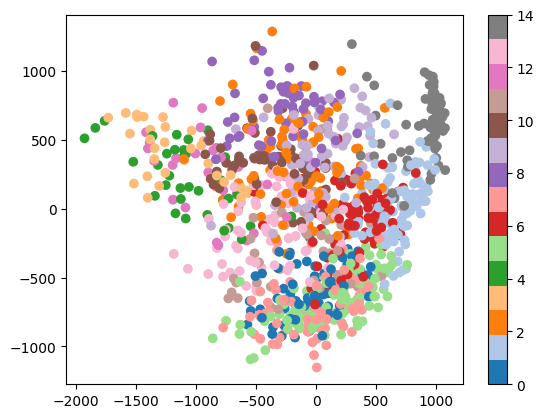

In [ ]:
#@title Scatterplot for dimension reduction

from collections import Counter
from tqdm import tqdm
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import gaussian_kde

label = "kmeans" #@param ["no", "density", "true", "kmeans"]
kmeans_iterations=50 #@param{type:"number"}
kmeans_clusters=15 #@param{type:"number"}


def dist(v1,v2):
  return np.linalg.norm(v1-v2)

def random_v():
    i = np.random.randint(0, len(x2))
    return x2[i]

def average_v(vs):
  if vs!=[]:
    v = np.zeros(len(x2[vs[0]]))
    for v2 in vs:
      v += x2[v2]
    v /= len(vs)
  else:
    v = random_v()
  return v





#def cluster_info(ids):
#  ys = [y_train[i] for i in ids]
#  if ys==[]: return (-1,-1)
#  (y,freq) = Counter(ys).most_common(1)[0]
#  return (y,100*freq/len(ids))


def kmeans_labels():

  start = time.time()

  # start with empty clusters
  clusters = [[] for _ in range(kmeans_clusters)]

  for steps in tqdm(range(kmeans_iterations)):
    center = [average_v(cluster) for cluster in clusters]
    clusters = [[] for _ in range(kmeans_clusters)]

    for i in range(len(x2)):
      v = x2[i]
      closest_center = min(range(len(center)), key=lambda j: dist(v, center[j]))
      clusters[closest_center].append(i)

  # iterate through all clusters and assign labels
  y = [-1 for i in range(len(x2))]
  for k,c in enumerate(clusters):
    for i in c:
      y[i] = k

  print("kmeans took %s"%sec2str(time.time()-start))

  return y



def scatterplot(xs,ys, indices=[]):
  if label == "no":
    plt.scatter(xs, ys)
  elif label == "density":
    xys = np.vstack([xs, ys])
    zs = gaussian_kde(xys)(xys)
    plt.scatter(xs, ys, c=zs, cmap='viridis', s=10)
    plt.colorbar(label='Density')
  elif label == "true":
    if indices != []:
      labels = [y2[i] for i in indices]
    else:
      labels = y2
    plt.scatter(xs, ys, c=labels, cmap='tab10')
    plt.colorbar()
  elif label == "kmeans":
    labels = kmeans_labels()
    if kmeans_clusters>20:
      print("tab20 has only colors for 20 clusters")
    tab20 = plt.cm.get_cmap('tab20', 20)  # tab20 has 20 colors
    custom_cmap = ListedColormap(tab20.colors[:kmeans_clusters])
    plt.scatter(xs, ys, c=labels, cmap=custom_cmap)
    plt.colorbar()
  plt.show()


scatterplot(xs,ys)


Found 345 items


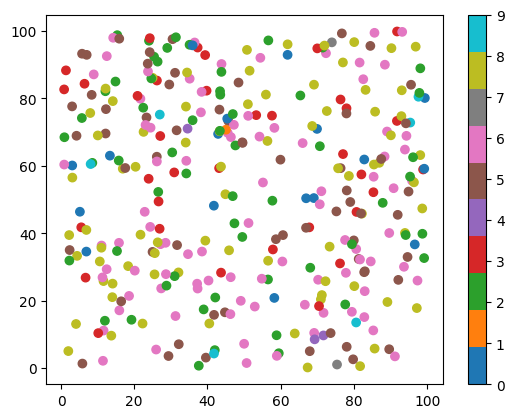

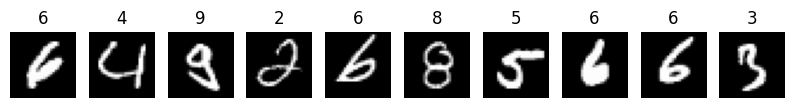

In [ ]:
#@title Zoom into xy range.

xy_range = "0,100,0,100" #@param{type:"string"}




def show(indices):

  if which == "mnist":
    n = len(indices)
    if n>10: n=10
    plt.figure(figsize=(n, 1))        # plot n digits next to each other
    for i,id in enumerate(indices[:n]):
      plt.subplot(1, n, i+1)
      plt.axis('off')
      plt.imshow(x2[id].reshape(28,28), cmap='gray')
      plt.title("%s"%y[id])
    plt.show()


  elif which=="spam":
    for id in indices:
      msg = decode(x[id]).strip()
      label = y_str[id]
      print("%s %s"%(label, msg))

  elif which == "restaurant":
    print("No show for restaurant")

[xs_min, xs_max, ys_min, ys_max] = [float(n) for n in xy_range.split(",")]
indices = [i for i in range(len(xy)) if xs[i]>xs_min and xs[i]<xs_max and ys[i]>ys_min and ys[i]<ys_max]
print("Found %d items"%len(indices))

scatterplot([xs[i] for i in indices],[ys[i] for i in indices], indices=indices)
show(indices)




In [ ]:
#@title Low-dimensional distance distribution. Step 1: Compute PCA and t-SNE

max_items = 10000 #@param{type:"number"}


from keras.datasets import mnist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

from tqdm import tqdm
import time, random, statistics
import matplotlib.pyplot as plt
import seaborn as sns




# pretty print for duration of running code
def sec2str(sec):

  minute, hour = 60, 60*60

  if   sec <= 1: return "less than 1 sec"
  elif sec <= minute: return "less than 1 min"
  elif sec < 2*minute: return "1:%02d min"%(int(sec)-minute)
  elif sec <= hour: return "%d:%02d min"%(int(sec/minute), int((sec%minute)))

  return "%d:%02d hours"%(int(sec/hour), (int(sec%hour)/minute))




(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_flattened = np.array([item.flatten() for item in x_train])
x2 = x_train_flattened[:max_items]
y2 = y_train[:max_items]

if max_items > len(x_train):
  max_items = len(x_train)
if max_items > 10000:
  print("t-SNE for %d items takes a considerable amount of time"%max_items)




start = time.time()
print("Computing PCA ", end="")
xy_pca = PCA(n_components=2).fit_transform(x2)
(xs_pca,ys_pca) = zip(*xy_pca)
print("took %s"%sec2str(time.time()-start))


start = time.time()
print("Computing t-SNE ", end="")
xy_tsne = TSNE(n_components=2).fit_transform(x2)
(xs_tsne,ys_tsne) = zip(*xy_tsne)
print("took %s"%sec2str(time.time()-start))







Computing PCA took less than 1 sec
Computing t-SNE took 2:21 min


In [ ]:

#@title Low-dimensional distance distribution. Step 2: Sample distances

max_pairs_percent = 0.1 #@param{type:"number"}
min_max_pairs = 10000
max_max_pairs = max_items*(max_items-1)/2
if max_pairs_percent <=0: max_pairs_percent=0.01
elif max_pairs_percent > 100: max_pairs_percent=100
max_pairs = max_pairs_percent*max_max_pairs



if max_pairs < min_max_pairs:
  print("max_pairs=%d is very small. I set it to %d"%(max_pairs, min_max_pairs))
  max_pairs = min_max_pairs
  print("It can be as big as %d"%max_max_pairs)
elif max_pairs > max_max_pairs:
  max_pairs = max_max_pairs
  print("max_pairs=%d is too large. I set it to %d"%(max_pairs, max_max_pairs))


print("You are sampling %d out of %d pairs"%(max_pairs,max_max_pairs))


def dist(v1,v2):
  return np.linalg.norm(v1-v2)



d1s = []
d2s_tsne = []
d2s_pca = []


pairs = set()
while len(pairs) < max_pairs:
    i, j = sorted(random.sample(range(10000), 2))
    pairs.add((i, j))
pairs = list(pairs)


for i, j in tqdm(pairs):
  d1 = dist(x2[i],x2[j])
  d2_tsne = dist(xy_tsne[i],xy_tsne[j])
  d2_pca = dist(xy_pca[i],xy_pca[j])
  d1s.append(d1)
  d2s_tsne.append(d2_tsne)
  d2s_pca.append(d2_pca)



You are sampling 4999500 out of 49995000 pairs


100%|██████████| 4999500/4999500 [02:03<00:00, 40347.63it/s]


High-dimensional distances:
min: 713 max: 3958 median: 2349 mean: 2365.20, std: 324.61
Low-dimensional distances (PCA):
min: 0 max: 3395 median: 920 mean: 968.96, std: 506.77
Low-dimensional distances (t-SNE):
min: 0 max: 176 median: 70 mean: 71.82, std: 34.33


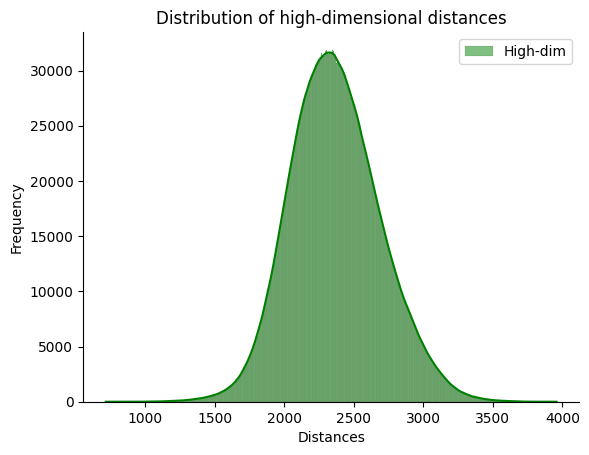

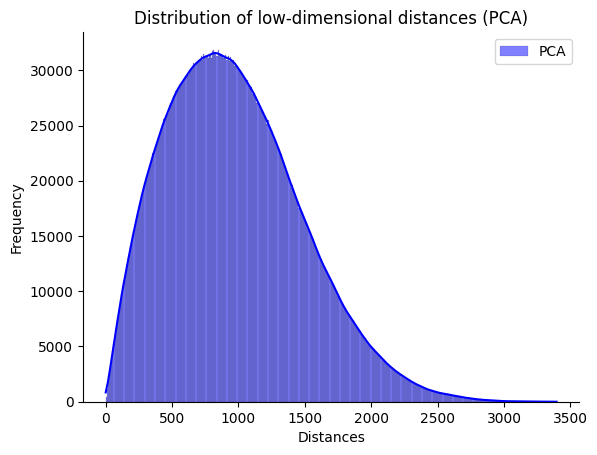

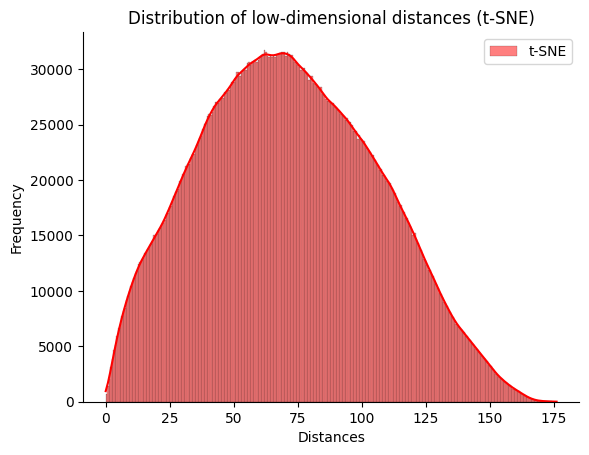

In [ ]:
#@title Low-dimensional distance distribution. Step 3: Plot histograms


def print_stats(s,values):
  m = statistics.mean(values)
  m2 = int(statistics.median(values))
  m3 = int(min(values))
  m4 = int(max(values))
  std = statistics.stdev(values)
  print("%s\nmin: %d max: %d median: %d mean: %.2f, std: %.2f"%(s,m3,m4,m2,m,std))


print_stats("High-dimensional distances:", d1s)
print_stats("Low-dimensional distances (PCA):", d2s_pca)
print_stats("Low-dimensional distances (t-SNE):", d2s_tsne)

sns.histplot(d1s, color='green', label='High-dim', kde=True)
sns.despine()
plt.title("Distribution of high-dimensional distances")
plt.xlabel("Distances")
plt.ylabel("Frequency")
plt.legend()
plt.show()

sns.histplot(d2s_pca, color='blue', label='PCA', kde=True)
sns.despine()
plt.title("Distribution of low-dimensional distances (PCA)")
plt.xlabel("Distances")
plt.ylabel("Frequency")
plt.legend()
plt.show()

sns.histplot(d2s_tsne, color='red', label='t-SNE', kde=True)
sns.despine()
plt.title("Distribution of low-dimensional distances (t-SNE)")
plt.xlabel("Distances")
plt.ylabel("Frequency")
plt.legend()
plt.show()


PCA and t-SNE are scaled to fit high-dimensional distances in the plot below
Low-dimensional distances (t-SNE):
min: 0 max: 3958 median: 1582 mean: 1614.61, std: 771.86
Low-dimensional distances (PCA):
min: 0 max: 3958 median: 1072 mean: 1129.57, std: 590.77


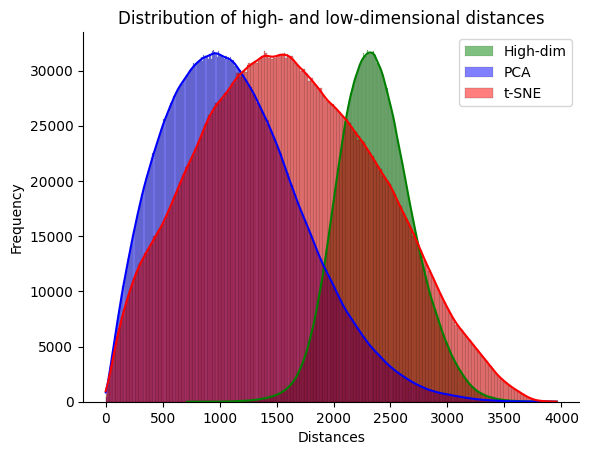

In [ ]:
#@title Low-dimensional distance distribution. Step 4: Plot scaled histograms on top of each other

scaling_factor_tsne = max(d1s) / max(d2s_tsne)
d2s_tsne_scaled = [scaling_factor_tsne*d for d in d2s_tsne]
scaling_factor_pca = max(d1s) / max(d2s_pca)
d2s_pca_scaled = [scaling_factor_pca*d for d in d2s_pca]

print("PCA and t-SNE are scaled to fit high-dimensional distances in the plot below")
print_stats("Low-dimensional distances (t-SNE):", d2s_tsne_scaled)
print_stats("Low-dimensional distances (PCA):", d2s_pca_scaled)

sns.histplot(d1s, color='green', label='High-dim', kde=True)
sns.histplot(d2s_pca_scaled, color='blue', label='PCA', kde=True)
sns.histplot(d2s_tsne_scaled, color='red', label='t-SNE', kde=True)
sns.despine()
plt.title("Distribution of high- and low-dimensional distances")
plt.xlabel("Distances")
plt.ylabel("Frequency")
plt.legend()
plt.show()


PCA and t-SNE are scaled to fit high-dimensional distances in the plot below
Low-dimensional distances (t-SNE):
min: 0 max: 3668 median: 306 mean: 443.34, std: 454.28
Low-dimensional distances (PCA):
min: 0 max: 3070 median: 244 mean: 340.23, std: 345.16


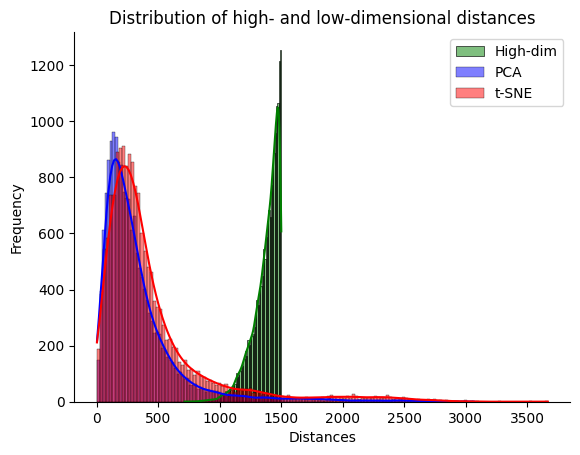

In [ ]:
#@title Low-dimensional distance distribution. Step 3: Plot histograms on top of each other

dist_cutoff = 1500 #@param{type:"number"}

d1s_short = [d1s[i] for i in range(len(d1s)) if d1s[i]<dist_cutoff]
scaling_factor_tsne = max(d1s) / max(d2s_tsne)
d2s_tsne_scaled_short = [scaling_factor_tsne*d for d,d1 in zip(d2s_tsne,d1s) if d1<dist_cutoff]
scaling_factor_pca = max(d1s) / max(d2s_pca)
d2s_pca_scaled_short = [scaling_factor_pca*d for d,d1 in zip(d2s_pca,d1s) if d1<dist_cutoff]


print("PCA and t-SNE are scaled to fit high-dimensional distances in the plot below")
print_stats("Low-dimensional distances (t-SNE):", d2s_tsne_scaled_short)
print_stats("Low-dimensional distances (PCA):", d2s_pca_scaled_short)


sns.histplot(d1s_short, color='green', label='High-dim', kde=True)
sns.histplot(d2s_pca_scaled_short, color='blue', label='PCA', kde=True)
sns.histplot(d2s_tsne_scaled_short, color='red', label='t-SNE', kde=True)
sns.despine()
plt.title("Distribution of high- and low-dimensional distances")
plt.xlabel("Distances")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [ ]:

#@title Simple K-means example

from collections import defaultdict
import matplotlib.pyplot as plt


data = [(11.,11.), (5.,2.), (1.,3.), (2.,2.), (10.,11.),(5.0,4.0),(20.,20.)]

def distance(xy1,xy2): # returns Manhattan distance
  (x1,y1),(x2,y2) = xy1,xy2
  return abs(x1-x2)+abs(y1-y2)

def closest(xys,xy1): # returns the index of the closest point
  return min(range(len(xys)), key=lambda i: distance(xy1,xys[i]))

def center(xys): # returns the average x and y
  return tuple([sum(l)/len(l) for l in zip(*xys)])

k = 4 # number of clusters
centers = data[:k] # first k points are initial cluster centers
clusters=defaultdict(list)

#################################
#
# Main loop
#
# Repeat assignment of nodes
# to nearest center and
# recalculate centers
#
#################################
for steps in range(10):
  clusters=defaultdict(list)
  for xy in data:
    nearest_center = closest(centers,xy)
    clusters[nearest_center].append(xy)
  centers = [center(clusters[oldCenter]) for oldCenter in clusters]

#################################
#
# Plot the resulting clustering
# with mathplotlib.
# Try to make it nicer with seaborn!
#
#################################
x,y,col=[],[],[]
for center in clusters:
  for xy in clusters[center]:
    x.append(xy[0])
    y.append(xy[1])
    col.append(center)
plt.scatter(x, y, c=col)
plt.show()

In [ ]:
#@title K-means for mnist

from keras.datasets import mnist
import numpy as np
from collections import Counter
from tqdm import tqdm
from matplotlib import pyplot as plt

iterations=10 #@param{type:"number"}
max_images=50 #@param{type:"number"}
n_clusters=15 #@param{type:"number"}



# load mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()




def dist(img1,img2):
  v1 = img1.flatten()
  v2 = img2.flatten()
  return np.linalg.norm(v1-v2)

def random_image():
    i = np.random.randint(0, min(max_images, len(x_train)))
    return x_train[i]

def average_image(ids):
  if ids!=[]:
    x = np.zeros((28,28))
    for i in ids:
      x += x_train[i]
    x /= len(ids)
  else:
    x = random_image()
  return x





def cluster_info(ids):
  ys = [y_train[i] for i in ids]
  if ys==[]: return (-1,-1)
  (y,freq) = Counter(ys).most_common(1)[0]
  return (y,100*freq/len(ids))


# start with 10 empty clusters
clusters = [[] for _ in range(n_clusters)]

for steps in tqdm(range(iterations)):
  center = [average_image(cluster) for cluster in clusters]
  clusters = [[] for _ in range(n_clusters)]

  for i in range(min(max_images, len(x_train))):
    x = x_train[i]
    closest_center = min(range(len(center)), key=lambda j: dist(x, center[j]))
    clusters[closest_center].append(i)

print()
label_freq = [cluster_info(ids) for ids in clusters]
for i,(l,f) in enumerate(sorted(label_freq, key=lambda x:x[0])):
  print("%d. Most frequent label %d (%.2f%%) n=%d"%(i,l,f, len(clusters[i])))


100%|██████████| 10/10 [00:00<00:00, 77.97it/s]


0. Most frequent label 0 (100.00%) n=1
1. Most frequent label 1 (50.00%) n=2
2. Most frequent label 1 (66.67%) n=3
3. Most frequent label 1 (100.00%) n=1
4. Most frequent label 1 (33.33%) n=5
5. Most frequent label 2 (100.00%) n=3
6. Most frequent label 3 (66.67%) n=6
7. Most frequent label 3 (100.00%) n=1
8. Most frequent label 4 (100.00%) n=5
9. Most frequent label 4 (100.00%) n=2
10. Most frequent label 6 (100.00%) n=2
11. Most frequent label 7 (100.00%) n=1
12. Most frequent label 8 (40.00%) n=5
13. Most frequent label 9 (60.00%) n=9
14. Most frequent label 9 (60.00%) n=4


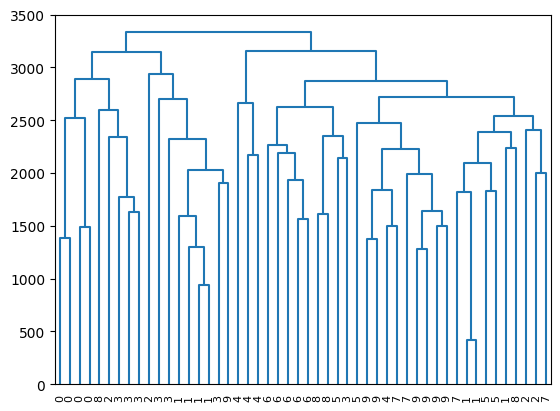

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_train_flat_small = x_train_flat[:max_images]
y_train_small = y_train[:max_images]

Z = linkage(x_train_flat_small, method='complete')

dendrogram(Z, leaf_rotation=90,
           color_threshold=0.5,
           leaf_font_size=8, leaf_label_func=lambda x: y_train_small[x])
plt.show()



In [ ]:
print()
label_freq = [cluster_info(ids) for ids in clusters]
for i,(l,f) in enumerate(label_freq):
  print("%d. Most frequent label %d (%.2f%%) n=%d"%(i,l,f, len(clusters[i])))



0. Most frequent label 0 (89.11%) n=2765
1. Most frequent label 3 (65.17%) n=4241
2. Most frequent label 0 (95.02%) n=2689
3. Most frequent label 1 (79.65%) n=3760
4. Most frequent label 1 (71.60%) n=5095
5. Most frequent label 3 (42.71%) n=5090
6. Most frequent label 7 (43.14%) n=4916
7. Most frequent label 4 (45.50%) n=4347
8. Most frequent label 2 (94.99%) n=4367
9. Most frequent label 5 (49.07%) n=3495
10. Most frequent label 6 (88.15%) n=2667
11. Most frequent label 7 (94.18%) n=2988
12. Most frequent label 6 (84.66%) n=3591
13. Most frequent label 9 (45.35%) n=5572
14. Most frequent label 8 (74.80%) n=4417


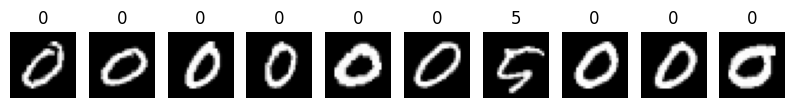

In [ ]:
#@title Show random cluster members
which_cluster=0 #@param{type:"number"}

def show(x,y, y_pred=None):
  n = len(x)
  plt.figure(figsize=(n, 1))        # plot n digits next to each other
  for i in range(n):
    plt.subplot(1, n, i+1)
    plt.axis('off')
    plt.imshow(x[i].reshape(28,28), cmap='gray')

    if y_pred is not None:          # print true and poredicted label
      plt.title("%d/%d"%(y[i],y_pred[i]))
    else:
      plt.title("%s"%y[i])
  plt.show()

if which_cluster<len(clusters):
  ids = clusters[which_cluster]
  selection = [ids[np.random.randint(0, len(ids))] for _ in range(10)]
  show(x_train[selection], y_train[selection])
else:
  print("which_cluster must be between 0 and %d"%(len(clusters)))



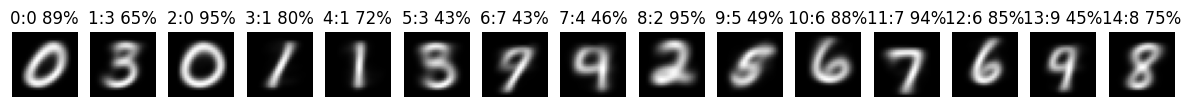

In [ ]:
#@title Print the cluster centers
y = ["%d:%d %.0f%%"%(i, label_freq[i][0], label_freq[i][1]) for i in range(len(center))]
show(center, y)



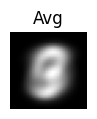

In [ ]:
#@title The average mnist image

x = [average_image(range(len(x_train)))]
y = ["Avg"]
show(x, y)

In [ ]:
ax.fig.add_subplot(111, projection='3d')
plt.imshow(x.reshape(28,28,), cmap='gray')
plt.show()

In [ ]:
#@title How many pixels in mnist are entirely black?

x = average_image(range(len(x_train)))
print("There are %d pixels, which are black in all mnist training images"%sum([1 for pixel in x.flatten() if pixel==0]))
print("There are %d pixels, which are <=1 in all mnist training images"%sum([1 for pixel in x.flatten() if pixel<=1]))
print("There are %d pixels, which are <=10 in all mnist training images"%sum([1 for pixel in x.flatten() if pixel<=10]))
print("There are %d pixels, which are <=127 in all mnist training images"%sum([1 for pixel in x.flatten() if pixel<=127]))

There are 67 pixels, which are black in all mnist training images
There are 282 pixels, which are <=1 in all mnist training images
There are 414 pixels, which are <=10 in all mnist training images
There are 770 pixels, which are <=127 in all mnist training images


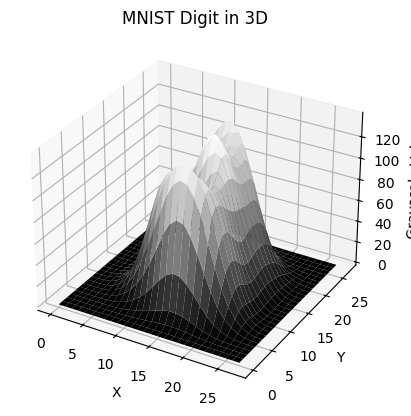

In [ ]:
#@title The average mnist image in 3D

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

image = average_image(range(len(x_train)))

x = np.linspace(0, 27, 28)
y = np.linspace(0, 27, 28)
x, y = np.meshgrid(x, y)

z = image

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x, y, z, cmap='gray')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Grayscale Value')
ax.set_title('MNIST Digit in 3D')

plt.show()


# 8 Unsupervised leanring with dimension reduction PCA and t-SNE

This ocde illustrates how PCA rotates and shifts data along the main axes, which we can exploit to reduce the data's dimensionality.

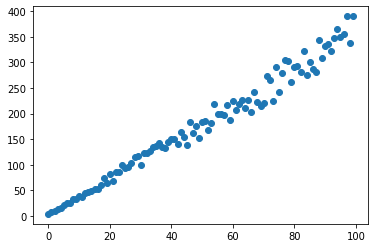

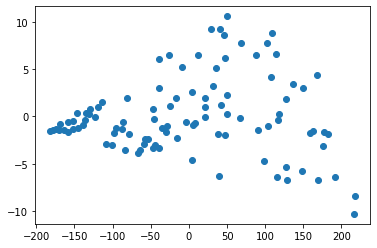

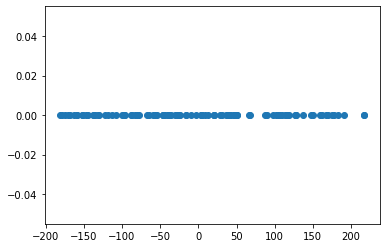

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import math
import random

xs = range(0,100,1)
ys = [(3+random.random())*x+3+random.random() for x in xs]


plt.scatter(xs, ys)
plt.show()

data = list(zip(xs,ys))
data2 = PCA(n_components=2).fit_transform(data)
(xs,ys) = zip(*data2)
plt.scatter(xs, ys)
plt.show()

data2 = PCA(n_components=1).fit_transform(data)
plt.scatter(data2, [0]*len(data2))
plt.show()





# 8 Unsupervised learning PCA for categorical data

PCA is a great way to visualise high-dimensional data. Even if it is categorical, PCA can be useful. Here we map the data of the restaurant example to numerical values and can apply PCA to see the examples in 2D. The visualisation reveals that there are no clear cut clusters for the "wait" and "don't wait" decisions, which means that linear methods are unlikely to work, while non linear methods should be more adequate.

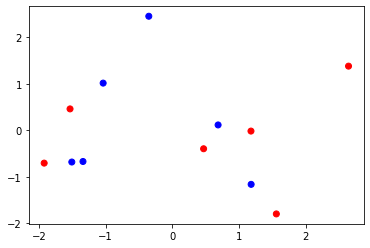

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data = [
["NearbyAlternative",  "Bar",  "Friday/Saturday",  "Hungry",  "Patrons",   "Price",  "Rain",  "Reservation",  "Type",     "Estimated Wait",    "Wait"],
#"Alt",  "Bar",  "Fri",  "Hun",  "Pat",   "Price",  "Rain",  "Res",  "Type",     "Est",    "Wait"],
["Yes",  "No",   "No",   "Yes",  "Some",  "$$$",    "No",    "Yes",  "French",   "0-10",   "Yes"],
["Yes",  "No",   "No",   "Yes",  "Full",  "$",      "No",    "No",   "Thai",     "30-60",  "No"],
["No",   "Yes",  "No",   "No",   "Some",  "$",      "No",    "No",   "Burger",   "0-10",   "Yes"],
["Yes",  "No",   "Yes",  "Yes",  "Full",  "$",      "No",    "No",   "Thai",     "10-30",  "Yes"],
["Yes",  "No",   "Yes",  "No",   "Full",  "$$$",    "No",    "Yes",  "French",   ">60",    "No"],
["No",   "Yes",  "No",   "Yes",  "Some",  "$$",     "Yes",   "Yes",  "Italian",  "0-10",   "Yes"],
["No",   "Yes",  "No",   "No",   "None",  "$",      "Yes",   "No",   "Burger",   "0-10",   "No"],
["No",   "No",   "No",   "Yes",  "Some",  "$$",     "Yes",   "Yes",  "Thai",     "0-10",   "Yes"],
["No",   "Yes",  "Yes",  "No",   "Full",  "$",      "Yes",   "No",   "Burger",   ">60",    "No"],
["Yes",  "Yes",  "Yes",  "Yes",  "Full",  "$$$",    "No",    "Yes",  "Italian",  "10-30",  "No"],
["No",   "No",   "No",   "No",   "None",  "$",      "No",    "No",   "Thai",     "0-10",   "No"],
["Yes",  "Yes",  "Yes",  "Yes",  "Full",  "$",      "No",    "No",   "Burger",   "30-60",  "Yes"]
]

header = data[0] # header from data
data = data[1:]      # remove header from data

val2int =  {
    "Yes": 0, "No": 1,
    "None": 0, "Some": 1, "Full": 2,
    "$$$": 0, "$$": 1, "$": 2,
    "French": 0, "Thai": 1, "Burger": 2, "Italian": 3,
    "0-10":0, "10-30": 1, "30-60": 2, ">60": 3
    }

val2col = {
    "Yes": "blue", "No": "red"
}

data2 = [[val2int[val] for val in example[:-1]] for example in data]

col = [val2col[example[-1]] for example in data]

data3 = PCA(n_components=2).fit_transform(data2)
(x,y) = zip(*data3)
plt.scatter(x, y, c=col)
plt.show()


# OLD MATERIAL BELOW

----------------------------------------

# 2 Breadth first search runtime

Here are two implementations of BFS with runtime of $O(b^d)$ and $O(b^{d+1})$, respectively. The code is reduced to the bare minimum. We do not explicitly represent the tree, but just define that node $n$ has children $2n$ and $2n+1$. We use a list as queue for the nodes and use pop(0) to get the first element. (By the way, what happens if you use pop() instead?)

bfs1 and bfs2 differ only in their if statements. bfs1 tests whether the current node is the goal and bfs whether the children to be appended to the q are the goal node.

Mathplotlib is then used to show the difference in runtime that bfs1 and bfs2 achieve.

Fun task: Search the web for code or pseudo code implementing bfs and check whether they implement the algorithm in $O(b^d)$ or $O(b^{d+1})$. If it is $O(b^{d+1})$, then think what you would need to change to achieve $O(b^d)$. (Note, much of the code you will find, implements complete graph traversal, so that the problem does not arise.)

100%|██████████| 19/19 [00:05<00:00,  3.23it/s]


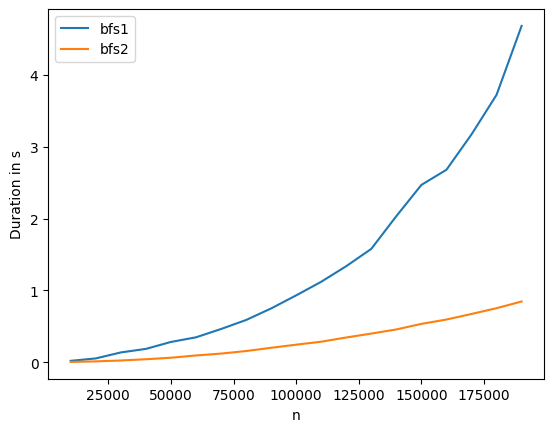

In [ ]:
import time
import matplotlib.pyplot as plt
from tqdm import tqdm # progressbar

def bfs1(goal):
  q = [1]
  while q:
    n = q.pop(0)
    if n==goal: return goal
    q.append(2*n)
    q.append(2*n+1)

def bfs2(goal):
  if 1 == goal: return 1
  q = [1]
  while q:
    n = q.pop(0)
    if 2*n  ==goal: return goal
    if 2*n+1==goal: return goal
    q.append(2*n)
    q.append(2*n+1)

def bfs(which, goal):
  t=time.time()
  if which==1: bfs1(goal)
  if which==2: bfs2(goal)
  return time.time()-t

x=range(10000,200000,10000)
plt.plot(x, [bfs(1, goal) for goal in tqdm(x)], label="bfs1")
plt.plot(x, [bfs(2, goal) for goal in tqdm(x)], label="bfs2")
plt.ylabel('Duration in s')
plt.xlabel('n')
plt.legend()
plt.show()


#3 The A\* algorithm

Kern der A\* Suche ist eine priority queue, in der die zu besuchenden Knoten gemäß einer Bewertung abgelegt sind. Die Bewertung beinhaltet die bisherigen Kosten und eine Abschätzung zum Ziel.

Frage: Im obigen Code ist bfs1 langsamer als bfs2. Genau wie bfs1 prüft der A\* Code, ob der gegenwärtige Knoten der Zielknoten ist. Könnte man den A* Code, so ändern, dass er eher bfs2 entspricht? Warum nicht?

In [ ]:
from heapq import heappush, heappop # priority queue
from collections import defaultdict

s="""
Arad, Zerind, 75
Arad, Sibiu, 140
Arad, Timisoara, 118
Zerind, Oradea, 71
Oradea, Sibiu, 151
Timisoara, Lugoj, 111
Sibiu, Fagaras, 99
Sibiu, Rimnicu Vilcea, 80
Lugoj, Mehadia, 70
Fagaras, Bucharest, 211
Rimnicu Vilcea, Pitesti, 97
Rimnicu Vilcea, Craiova, 146
Mehadia, Dobreta, 75
Bucharest, Pitesti, 101
Bucharest, Urziceni, 85
Bucharest, Giurglu, 90
Pitesti, Craiova, 138
Craiova, Dobreta, 120
Urziceni, Hirsova, 98
Urziceni, Vaslui, 142
Hirsova, Eforie, 86
Vaslui, Lasi, 92
Lasi, Neamt, 87
"""

to = defaultdict(set)
for line in s.split("\n"):
  if line:
    [city1, city2, dist] = [t.strip() for t in line.split(",")]
    to[city1].add( (city2, int(dist)) )
    to[city2].add( (city1, int(dist)) )

s="""
Arad, 366
Bucharest, 0
Craiova, 160
Dobreta, 242
Eforie, 161
Fagaras, 176
Giurgiu, 77
Hirsowa, 151
Lasi, 226
Lugoj, 244
Mehadia, 241
Neamt, 234
Oradea, 380
Pitesti, 100
Rimnicu Vilcea, 193
Sibiu, 253
Timisoara, 329
Urziceni, 80
Vaslui, 199
Zerind, 374
"""

sld = {}
for line in s.split("\n"):
  if line:
    [city, dist] = [t.strip() for t in line.split(",")]
    sld[city]=int(dist)

def astar(start, stop):
  f = sld[start] # f = g+h = 0+sld[start]
  path = [start]
  first = (f, path)
  q = [] # priority queue for nodes sorted by f
  heappush(q,first)
  while q:
    (f,path) = heappop(q)
    n = path[-1] # n is current node
    if n==stop: # is current node the destination?
      return path # then we are done
    elif n in to:
      for (n2, dist) in to[n]: # for all neighbours of current city
        f2 = f-sld[n]+dist+sld[n2] # f=g+h, f2=g2+h2, g2=g+dist, so f2=f-h+dist+h2
        heappush(q, (f2, path+[n2]))

print("Best route: "+", ".join(astar("Arad", "Bucharest")))


Best route: Arad, Sibiu, Rimnicu Vilcea, Pitesti, Bucharest


# 4 Boyer-Morre vs. naive string search

How does python's find compare to a naive string search algorithm. find2 checks for every position in s whether string t can be found. find1 simply uses Python's find, which implements the Boyer-Moore algorithm. We evaluate runtimes on strings of the form a...ab to highlight the strength of Boyer-Moore, which can jump forward in the string s by the lenth of string t if the last is not matching. As a result is achieves what appears to be constant runtime in contrast to the naive implementation. Upon closer inspection of the Boyer-Moore runtime it is of course not constant, as string t needs to be pre-processed and string s is nonetheless searched.

In [ ]:
import matplotlib.pyplot as plt
import time
from tqdm import tqdm # progressbar

def find1(s,t):
  return s.find(t)

def find2(s,t):
    """Checks if t appears in string s by incrementally checking each position in s."""
    cs=0
    ct=0
    while ct<len(t) and cs<len(s):
        if s[cs]==t[ct]:
            ct+=1
        else:
            cs=cs-ct
            ct=0
        cs+=1
    if ct==len(t):
        return cs-len(t)
    else:
        return -1

#print(find2("ababaccccc","abac"))


def test(which,s,t):
  start=time.time()
  if which==1: find1(s,t)
  else:        find2(s,t)
  return time.time()-start

x,y,z1,z2=[],[],[],[]
for n in tqdm(range(0,50000,1000)):
  for m in range(0,n,1000):
    s= "a"*n + "b"
    t= "a"*m + "b"
    x.append(n)
    y.append(m)
    z1.append(test(1,s,t))
    z2.append(test(2,s,t))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z1, label="find1 (Boyer Moore)", marker="o")
ax.scatter(x, y, z2, label="find2 (naive)", marker="x")
ax.set_xlabel('n')
ax.set_ylabel('m')
ax.set_zlabel('time')
plt.legend()
plt.show()

plt.plot(sorted(z1), label="find1 (Boyer Moore)", marker="o")
plt.plot(sorted(z2), label="find2 (naive)", marker="x")
plt.xlabel('sorted time values')
plt.ylabel('time')
plt.legend()
plt.show()

plt.plot(sorted(z1), label="find1 (Boyer Moore)", marker="o")
plt.xlabel('sorted time values')
plt.ylabel('time')
plt.legend()
plt.show()


 70%|███████   | 35/50 [6:01:31<8:15:38, 1982.57s/it]

# 4 Levenshtein distance

In [ ]:
#AB03.4
#@title Input strings for Levensthein distance { display-mode: "code" }
a = "Peter" #@param {type:"string"}
b = "Petra" #@param {type:"string"}


def lev(a,b):
  d, m, n = {}, len(a), len(b)
  for i in range(0,m+1): d[i,0] = i
  for j in range(1,n+1): d[0,j] = j
  for i in range(1,m+1):
    for j in range(1,n+1):
      if a[i-1] == b[j-1]: s = 0
      else: s = 1
      d[i,j] = min(d[i-1,j  ]+1,
                   d[i  ,j-1]+1,
                   d[i-1,j-1]+s)
  return d[m,n]

def dice(a,b):
  if len(a)<3 or len(b)<3: return 0.0
  tri_a = {a[i:i+3] for i in range(len(a)-2)}
  tri_b = {b[i:i+3] for i in range(len(b)-2)}
  return 2.0*len(tri_a.intersection(tri_b)) / (len(tri_a) + len(tri_b))

print("Levenshtein distance between %s and %s is %d, dice coefficient is %.2f"%(a,b,lev(a,b),dice(a,b)))


Levenshtein distance between Peter and Petra is 2, dice coefficient is 0.33


# 4 Levenshtein vs. dice

We explore how both distances relate to each other.


Analysed 13442 randomly selected pairs of words from a wiki article.
Words had to be longer than 6. Some Examples:

a                  b                    lev    dice
-----------------  -----------------  -----  ------
sub-problems.      problem                6    0.62
intelligence       super-intelligent      8    0.64
computers          human–computer         7    0.63
Hyper-intelligent  intelligence,          9    0.62
Research           researchers            4    0.67



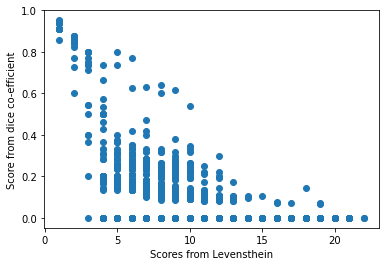

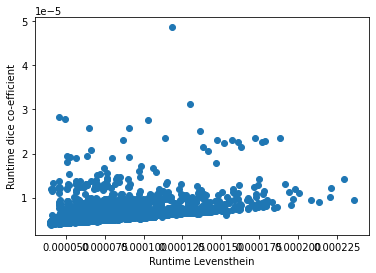

In [ ]:

!pip -q install wikipedia
import wikipedia
import random
import matplotlib.pyplot as plt
from tabulate import tabulate

def lev(a,b):
  d, m, n = {}, len(a), len(b)
  for i in range(0,m+1): d[i,0] = i
  for j in range(1,n+1): d[0,j] = j
  for i in range(1,m+1):
    for j in range(1,n+1):
      if a[i-1] == b[j-1]: s = 0
      else: s = 1
      d[i,j] = min(d[i-1,j  ]+1,
                   d[i  ,j-1]+1,
                   d[i-1,j-1]+s)
  return d[m,n]

def dice(a,b):
  if len(a)<3 or len(b)<3: return 0.0
  tri_a = {a[i:i+3] for i in range(len(a)-2)}
  tri_b = {b[i:i+3] for i in range(len(b)-2)}
  return 2.0*len(tri_a.intersection(tri_b)) / (len(tri_a) + len(tri_b))

ls,lts,ds,dts = [],[],[],[]
s=wikipedia.page("artificial intelligence").content
words = s.split()
total=0
len_cutoff = 6 # words have to be longer than this
max_examples = 10
examples = [["a","b","lev","dice"]]
for i in range(100000):
  a = words[random.randrange(len(words))]
  b = words[random.randrange(len(words))]

  if a!=b and len(a)>len_cutoff and len(b)>len_cutoff:
    total+=1
    t=time.time()
    l = lev(a,b)
    lt = time.time()-t
    ls.append(l)
    lts.append(lt)

    t=time.time()
    d = dice(a,b)
    dt = time.time()-t
    ds.append(d)
    dts.append(dt)

    if d>0.6 and d<0.7 and len(examples)<max_examples:
      examples.append([a,b,l,round(d,2)])

print()
print("Analysed %d randomly selected pairs of words from a wiki article."%total)
print("Words had to be longer than %d. Some Examples:"%len_cutoff)
print()
print(tabulate(examples, headers="firstrow"))
print()

plt.scatter(ls,ds)
plt.xlabel('Scores from Levensthein')
plt.ylabel('Score from dice co-efficient')
plt.show()

plt.scatter(lts,dts)
plt.xlabel('Runtime Levensthein')
plt.ylabel('Runtime dice co-efficient')
plt.show()

# 5 HMM

In [ ]:
from collections import defaultdict
from tabulate import tabulate


data="""
SPPOOOOLE $ John Denver will be playing in Denver €
SLOOOOLE  $ Denver is a city in Colorado €
SPOPOOLE  $ John and Paris went to Washington €
SOOOOPPE  $ The Oscar goes to Denzel Washington €
SPOOLE    $ Oscar lives in Washington €
"""

class prob():
    """Counts occurances for a pair of keys (either state to state or state to observation)
    as well as frequency of first state overall. Output are probability to transition/emission."""

    def __init__(self):
        self.c=defaultdict(int)
        self.n=defaultdict(int)
        self.p=defaultdict(float)

    def inc(self,k1,k2):
        self.c[(k1,k2)] += 1
        self.n[k1] += 1

    def prob(self):
        for (k1,k2) in self.c:
            self.p[(k1,k2)] = float(self.c[(k1,k2)]) / float(self.n[k1])
        return self.p

def readTraining():
    """Data format: First word rpresents state sequence. Remaining words are observations.
    For each character in the first word, there must be a word following.
    Start state is S, End state is E
    """
    t=prob()
    e=prob()
    for line in data.strip().split("\n"):
        l = line.split()
        seq=list(l[0])
        obs=l[1:]
        if len(seq)!=len(obs):
            print("Format error in line %s"%(line))
        else:
            # Count transitions
            for i in range(len(seq)-1):
                t.inc(seq[i],seq[i+1])
            # Count emissions
            for i in range(len(seq)):
                e.inc(seq[i],obs[i])
    return (t.prob(), e.prob())

def max_pos(l):
    """Returns the maximum and its position."""
    m = max(l)
    return(l.index(m),m)

####################################################
#
# Viterbi is the main method
#
####################################################

def viterbiAlg(str, transition, emission):
    viterbi={} # dynamic programming matrix
    pos={}     # matrix to record path for backtracking
    obs = str.split()
    states = list(set([s for (s,o) in emission]))
    # Init
    for s in states:
        viterbi[(s,0)]= float(s=="S")
    # Fill matrix
    for i in range(1,len(obs)):
        for j in states:
            # Fji = max F(r,i-1)*A(r,j)*B(j,i)
            (pos[(j,i)],viterbi[(j,i)]) = max_pos([viterbi[(r,i-1)]*transition.get((r,j),0.0)*emission.get((j,obs[i]),0.0) for r in states])
    # Output table
    table = [[""]+ obs]
    for s in states:
        row = [s]
        for i in range(len(obs)):
            row.append(viterbi[(s,i)])
        table.append(row)
    s = "E"
    seq= ["E"]
    for i in range(len(obs)-1,0,-1):
        s = states[pos[(s,i)]]
        seq.insert(0,s)
    table.append([""]+seq)
    print()
    print(tabulate(table, headers="firstrow"))

#######################################################
#
# Main method
#
#######################################################

transition={}
emission={}
(transition, emission) = readTraining()
observations = set([o for (s,o) in emission])

print()
print("Transitions:")
t = sorted(transition.items(), key=lambda x: x[1], reverse=True)
for ((s1,s2),v) in t:
    print("%s -> %s: %0.2f"%(s1,s2,v))

print()
print("Emissions:")
e = sorted(emission.items(), key=lambda x: x[1], reverse=True)
for ((s,o),v) in e:
    print("%s -> %s: %0.2f"%(s,o,v))

print()
print("Write a sentence using the vocabulary above.")
print("E.g. Oscar went to Denzel or Oscar went to Washington.")
s= input()
viterbiAlg("$ "+s+" €", transition, emission)




Transitions:
L -> E: 0.80
O -> O: 0.65
S -> P: 0.60
P -> O: 0.57
P -> P: 0.29
O -> L: 0.24
S -> L: 0.20
L -> O: 0.20
S -> O: 0.20
P -> E: 0.14
O -> P: 0.12

Emissions:
S -> $: 1.00
E -> €: 1.00
L -> Denver: 0.40
L -> Washington: 0.40
P -> John: 0.29
L -> Colorado: 0.20
O -> in: 0.18
P -> Denver: 0.14
P -> Paris: 0.14
P -> Denzel: 0.14
P -> Washington: 0.14
P -> Oscar: 0.14
O -> to: 0.12
O -> will: 0.06
O -> be: 0.06
O -> playing: 0.06
O -> is: 0.06
O -> a: 0.06
O -> city: 0.06
O -> and: 0.06
O -> went: 0.06
O -> The: 0.06
O -> Oscar: 0.06
O -> goes: 0.06
O -> lives: 0.06

Write a sentence using the vocabulary above.
E.g. Oscar went to Denzel or Oscar went to Washington.
Oscar went to Paris

    $    Oscar                 went                  to                      Paris                   €
--  ---  --------------------  --------------------  ----------------------  ----------------------  ---------------------
E   0.0  0.0                   0.0                   0.0                 

# 5 Progressive alignment

The code implements progressive alignment. Given a list of strings, they are one by one aligned. The base is the Levenshtein distance and alignment function, but instead of strings alignments are compared. Overall, the code looks very similar to the basic Levenshtein, yet all of the indices may be confusing. But it works! The key is that we move from using a[i] to access a letter in string to an alignment. It is represented as a list of strings. The function get(a,i) takes this list and returns a list of the letters at position i for all of the strings in a.

In [ ]:
def cmp(a,b):
    """Returns the score for comparing a and b, which may be characters or the gap symbol."""
    if a==b and a!="-":
        return 0
    elif a=="-" or b=="-":
        return 1
    else:
        return 1.5

def sum_of_pairs(aa,bb):
    """Computes the sum of pairs of all characters in string aa against all characters in string bb.

    aa and bb are alignments and may contain the gap symbol."""
    c=0
    for a in aa:
        for b in bb:
            c+=cmp(a,b)
    return c

def min_dir(a,b,c):
    """Returns the minimum value of a, b, and c and which are minimal.

    c is encoded as NW, b as N and a as W.
    More than one can be the minimum.
    Preference is given to NW, then N, then W.
    This means that alignments with match/mismatch
    from end to front are preferred. If all alignments
    are needed, then the function has to return a set of directions
    instead of single direction."""
    if c==min(a,b,c):
        return (c,"NW")
    if b==min(a,b,c):
        return (b,"N")
    if a==min(a,b,c):
        return (a,"W")

def align(a,b,d_dir,i,j):
    """Outputs the alignment of alignments a and b up to position i and j given the direction matrix d_dir.

    Alignments a and b are lists of strings with the original character sequences possibly with gaps."""
    if i==0 and j==0:
        return [[""]*len(a),[""]*len(b)]
    elif d_dir[i,j]=="N":
        (a2,b2)=align(a,b,d_dir,i,j-1)
        return [add(a2,gap(a)),add(b2,get(b,j-1))]
    elif d_dir[i,j]=="W":
        (a2,b2)=align(a,b,d_dir,i-1,j)
        return [add(a2,get(a,i-1)), add(b2,gap(b))]
    elif d_dir[i,j]=="NW":
        (a2,b2)=align(a,b,d_dir,i-1,j-1)
        return [add(a2,get(a,i-1)), add(b2,get(b,j-1))]

def get(a,i):
    """Returns the list of characters at position i in the alignment a, which is a list of strings."""
    return [s[i] for s in a]

def add(a,aas):
    """Given a list of n strings (an alignment) and a list of n characters, add appends character i to string i."""
    a2=[]
    for i in range(len(a)):
        a2.append(a[i]+aas[i])
    return a2

def ins(a,b):
    """Returns the penalty for inserting/deleting into alignment a or b."""
    return len(a)*len(b)*gap

def gap(a):
    """Returns n gaps for an alignment of n sequences."""
    return ["-"]*len(a)

def lev2(a, b):
    """Align the two alignments a and b and return the common alignment and its score."""
    m = len(a[0])
    n = len(b[0])
    d = {}
    d_dir = {}
    d[(0, 0)] = 0
    d_dir[(0, 0)] = ""
    for i in range(1, m + 1):
        d[(i, 0)] = i*len(a)
        d_dir[(i, 0)] = "W"
    for j in range(1, n + 1):
        d[(0, j)] = j*len(b)
        d_dir[(0, j)] = "N"
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            (d[(i, j)],d_dir[(i, j)]) = min_dir(d[(i - 1, j)] + sum_of_pairs(get(a,i-1),gap(b)),
                                            d[(i, j - 1)] + sum_of_pairs(gap(a),get(b,j-1)),
                                            d[(i - 1, j - 1)] + sum_of_pairs(get(a,i-1),get(b,j-1)))
    (a1,a2)=align(a,b,d_dir,m,n)
    a1.extend(a2)
    return (d[(m, n)], a1)


def msaList(a):
    """Progressive alignment of the sequences in a.

    Succesively, the sequences in a are added to an alignment.
    The final alignment is returned."""
    b=[a[0]]
    for i in range(1,len(a)):
        (score,b) = lev2(b,[a[i]])
    return (score,b)


names=["Februar","February","Febbraio","Febrero","Fevrier"]

(s,a)=msaList(names)

for aa in a:
  print(aa)

Fe-bruar-
Fe-bruary
Febbr-aio
Fe-bre-ro
Fev-rier-


# 7 Argumentation

This programme computes justified arguments
using a fix point argumentation semantics.

Using different notions of attack such as undercuts, attacks, defeats, strong undercuts and attacks a proponent and opponent argue about the truth of conclusions. Depending on the strength of proponent and opponent, the semantics becomes more or less credulous.

Arguments are provided in the file arg_example.txt

Arguments follow a simple syntax:
 -a <- b.
 b <- not c,d.
 d <-.

Rules must be in one line.
Rules must end with a dot.
Rules must contain <- even if they are facts.
Objective literals --a (double negation) are not allowed
Just one rule per objective literal.

Since there is only one rule per objective literal,
we can identify this rule given its header objective literal.
In the code below an argument is only implicitly a set of rules.
Explicitly, it is nothing but a rule. However, the rule's objective
literals in its body are accepted, which means there exist rules for them.

In [ ]:
from tabulate import tabulate

data="""
p<-not q.
q<-not p.
-q<-not r.
s<-.
r<-not s.
-s<-not s.
"""


class literal():
    """An objective literal is either an atom A or a negated atom neg A.
    A default literal has the form not L, where L is an objective literal.
    A literal is either a default or an objective literal.

    You can use attributeds isDefault, isObjective, objective, isNeg, atom.
    """

    def __init__(self, s):
        s = s.strip()
        self.s = s
        self.isDefault = s.startswith("not")
        self.isObjective = not self.isDefault
        if self.isDefault:
            self.objective = s[3:].strip()
        else:
            self.objective = s
        self.isNeg = self.objective.startswith("-")
        if self.isNeg:
            self.atom = self.objective[1:]
        else:
            self.atom = self.objective


################################################
#
# Here are notions of attack
#
# These functions are not defined within the rule class,
# since we want to use them globally and pass them as
# parameters.
#
################################################

def rebuts(a, b):
    return a.head.atom == b.head.atom and (a.head.isNeg != b.head.isNeg)

def undercuts(a, b):
    for bodyLiteral in b.body:
        if bodyLiteral.isDefault and bodyLiteral.objective == a.head.objective:
            return True
    return False

def attacks(a, b):
    return rebuts(a,b) or undercuts(a,b)

def defeats(a, b):
    return undercuts(a,b) or (rebuts(a,b) and not undercuts(b,a))

def strongly_attacks(a, b):
    return attacks(a,b) and not undercuts(b,a)

def strongly_undercuts(a, b):
    return undercuts(a,b) and not undercuts(b,a)

class rule():
    """A rule has a head and a body. The head is an objective literal.
    The body is either empty or consists of objective and default literals.
    Syntax: head <- L1, not L2, ..."""

    def __init__(self, s):
        s = s.strip()
        self.s = s
        # remove dot at the end of the string and split at <-
        l = s.rstrip(".").split("<-")
        self.head = literal(l[0])
        if l[1]:
            # split body string at commas and convert items to literal using map.
            self.body = [literal(x) for x in l[1].split(",")]
        else:
            self.body = []

    def isArgument(self, S):
        """A rule is an argument if the objective literals in its body are in S.
        This means, there were rules for these objective literals, as required
        by the formal definition of an argument. Also the default literals in the
        body is must not yet be accepted."""
        for bodyLiteral in self.body:
            if bodyLiteral.isObjective and bodyLiteral.objective not in [x.head.objective for x in S]:
                return False
        return True

    def existsArgument(self, S, y, b):
        """There is an accepted argument in S, which y-attacks argument b"""
        for c in S:
            if y(c,b):
                return True
        return False

    def isAcceptable(self, S,x,y, arguments):
        """An argument a is acceptable if for all b, which  x-attack a,
        there is an accepted agument c, which y-attacks b."""
        for b in arguments:
            if x(b,self) and not self.existsArgument(S,y,b):
                return False
        return True

    def str(self):
        """Return a list of head and body string for use in tabulate."""
        return [self.head.s, "<-", ", ".join([x.s for x in self.body]), "."]


class arguments():

    def __init__(self, data):
        self.rules = self.read(data)
        self.s = self.str(self.rules)

    def str(self, rules2):
        """Returns tabulate of all rules in rules2."""
        return tabulate([r.str() for r in rules2])

    def str2(self, rules2):
        """Returns a string with all the heads of the rules in rules2."""
        return "{"+", ".join([r.head.s for r in rules2])+"}"

    def read(self, data):
        """Reads rules."""
        rules = []
        for line in data.strip().split("\n"):
            r = rule(line)
            rules.append(r)
        return rules

    def f(self, S,x,y):
        """Main function, which collects accetable arguments."""
        S2 = set([])
        for a in self.rules:
            if a.isArgument(S) and a.isAcceptable(S,x,y, self.rules):
                S2.add(a)
        return S2

    def justified(self, x, y):
        """Fixpoint semantics. Starting with the empty set, f is iteratively
        applied, until it reaches a fix point. In each step f computes the
        acceptable arguments wrt. the arguments accepted so far."""
        S=set([])
        i=0
        f_S = self.f(S,x,y)
        while f_S != S:
            #print("\nIteration %d for %s/%s justified arguments"%(i,x.__name__,y.__name__))
            #print("f(%s) = %s"%(self.str2(S), self.str2(f_S)))
            i+=1
            S = f_S
            f_S = self.f(S,x,y)
        return S



# Read rules and print them to screen
args = arguments(data)
print("\nRules:\n%s\n"%(args.s))

# Check all of the following notions of attack, as defined above
notions_of_attack = [undercuts, attacks, defeats, strongly_undercuts, strongly_attacks]
all = [["","x","y","Justified arguments"]]
i=0

# Check all combintations of notions of attack for proponent and opponent
for x in notions_of_attack:
    for y in notions_of_attack:
        i+=1
        # Compute the justified arguments
        just = args.justified(x,y)
        # And print them nicely
        #print("\n\nJustified arguments for x=%s and y=%s:\n%s\n"%(x.__name__, y.__name__,args.str(just)))
        all.append([i,x.__name__, y.__name__,", ".join([x.head.s for x in just])])

print("\n\n%s\n"%(tabulate(all, headers="firstrow")))


Rules:
--  --  -----  -
p   <-  not q  .
q   <-  not p  .
-q  <-  not r  .
s   <-         .
r   <-  not s  .
-s  <-  not s  .
--  --  -----  -



    x                   y                   Justified arguments
--  ------------------  ------------------  ---------------------
 1  undercuts           undercuts           -q, s
 2  undercuts           attacks             p, -q, s
 3  undercuts           defeats             p, -q, s
 4  undercuts           strongly_undercuts  -q, s
 5  undercuts           strongly_attacks    p, -q, s
 6  attacks             undercuts
 7  attacks             attacks
 8  attacks             defeats
 9  attacks             strongly_undercuts
10  attacks             strongly_attacks
11  defeats             undercuts           s
12  defeats             attacks             s
13  defeats             defeats             s
14  defeats             strongly_undercuts  s
15  defeats             strongly_attacks    s
16  strongly_undercuts  undercuts           p, q, -q

Below is some code to illustrate non-linear data, which cannot be handled with linear regression.

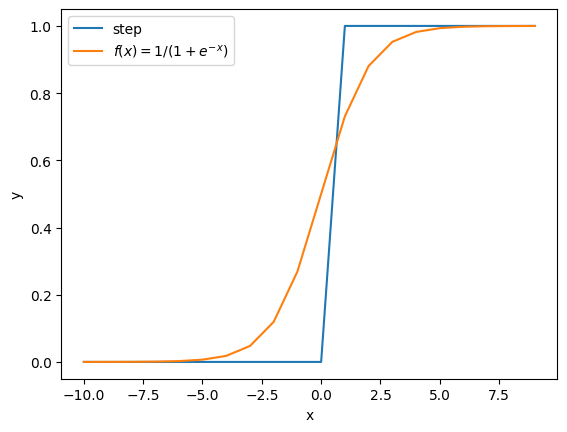

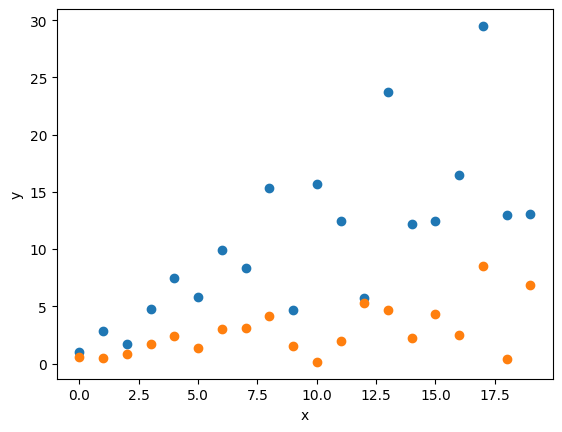

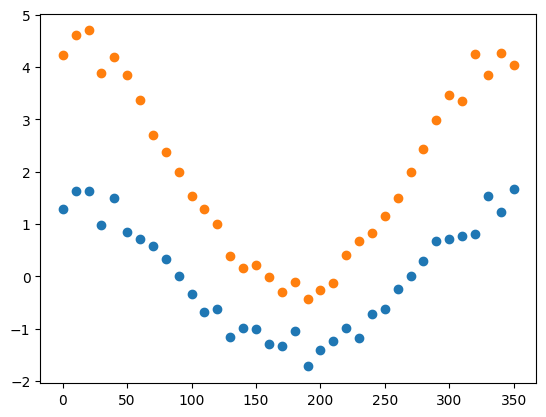

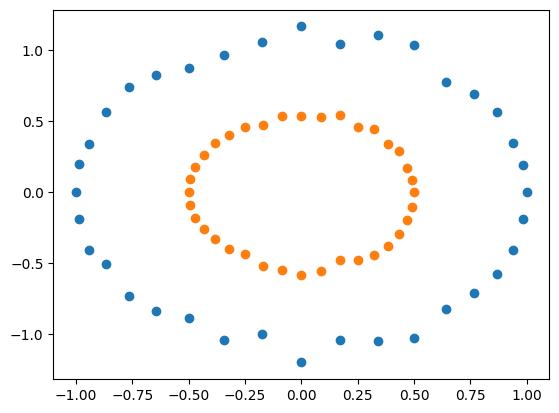

In [ ]:
import math
import random
import matplotlib.pyplot as plt


def logistic(x):
  return 1/(1+math.exp(-x))

def step(x):
  if x>0: return 1.0
  else: return 0.0

xs = range(-10,10,1)
plt.plot(xs,[step(x) for x in xs], label="step")
plt.plot(xs,[logistic(x) for x in xs], label="$f(x)=1/(1+e^{-x})$")
plt.ylabel("y")
plt.xlabel("x")
plt.legend()
plt.show()


def f1(x,a,b):
  return a*random.random()*x+b*random.random()

xs = range(0,20,1)
plt.scatter(xs,[f1(x,2,3) for x in xs])
plt.scatter(xs,[f1(x,0.5,1) for x in xs])
plt.ylabel("y")
plt.xlabel("x")
plt.show()

def f2(x,a,b,c):
  return (a+random.random())*math.cos(b*math.radians(x))+c

xs = range(0,360,10)
plt.scatter(xs,[f2(x,1,1,0) for x in xs])
plt.scatter(xs,[f2(x,2,1,2) for x in xs])
plt.show()


angles = [math.radians(alpha) for alpha in range(0,360,10)]
xs = [math.cos(angle) for angle in angles]
ys = [(1.0+random.random()*0.2)*math.sin(angle) for angle in angles]
plt.scatter(xs,ys)
xs = [0.5*math.cos(angle) for angle in angles]
ys = [(1.0+random.random()*0.2)*0.5*math.sin(angle) for angle in angles]
plt.scatter(xs,ys)
#plt.scatter(xs,[f2(x,-0.2,1.2,0) for x in xs])
plt.show()

[0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


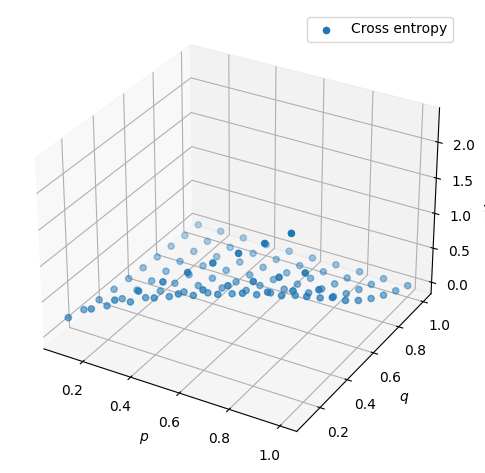

In [ ]:
import matplotlib.pyplot as plt

from math import log
values = [x * 0.1 for x in range(1,11)]
print(values)
l=[]
for p in values:
  for q in values:
    l.append([p,q,-p*log(q)])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ps,qs,pqs = zip(*l)
ax.scatter(ps, qs, pqs, label="Cross entropy", marker="o")
ax.set_xlabel('$p$')
ax.set_ylabel('$q$')
ax.set_zlabel('-p*log(q)', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()


# 10 Real neural networks

We will analyse a real neural networks of a worm. In a recent Nature paper, the authors analysed some 500 neurons and their connections. This is far from the billions neurons in a human brain, but it is the most detailed connectome known today. The most detailed interactions in mouse are connections between 213 brain regions, so no details on individual neurons. Humans? Nope.

We retrieve the data first. Unfortunately, it is in xls, but we read it from Python and then plot its connectivity patterns. We will find that a few neurons are highly connected and many have few connections.

It appears that artificial neural networks also evolve a power law topology (see Lou et al., Power Law in Sparsified Deep Neural Networks, bioarxiv), but they comprise far fewer nodes, which means leave open whether it is a valid comparison.

Retrieve the excel file with worm neural network.

In [ ]:
#!wget https://wormwiring.org/Cytoscape%20files/Fig.%201%20Hermaphrodite%20nervous%20system.cys
!wget https://wormwiring.org/si/SI%205%20Connectome%20adjacency%20matrices,%20corrected%20July%202020.xlsx

--2020-10-13 08:58:25--  https://wormwiring.org/si/SI%205%20Connectome%20adjacency%20matrices,%20corrected%20July%202020.xlsx
Resolving wormwiring.org (wormwiring.org)... 45.76.6.231
Connecting to wormwiring.org (wormwiring.org)|45.76.6.231|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4188190 (4.0M) [application/vnd.openxmlformats-officedocument.spreadsheetml.sheet]
Saving to: ‘SI 5 Connectome adjacency matrices, corrected July 2020.xlsx’

SI 5 Connectome adj 100%[===================>]   3.99M  2.78MB/s    in 1.4s    

2020-10-13 08:58:27 (2.78 MB/s) - ‘SI 5 Connectome adjacency matrices, corrected July 2020.xlsx’ saved [4188190/4188190]



openpyxl is a library, which reads and writes excel. We read the spreadsheet, which comprises the adjacency matrix of the network and turn it into a set of edges, which is much better representation as the network is sparse.

In [ ]:
from openpyxl import load_workbook
wb = load_workbook(filename = 'SI 5 Connectome adjacency matrices, corrected July 2020.xlsx')
ws = wb["male chemical"]

nameCol={}
for c in ws['D3':'VF3']:
  for d in c:
    nameCol[d.column] = d.value

nameRow={}
for c in ws['C4':'C385']:
  for d in c:
    nameRow[d.row] = d.value

edges = set([])

def order(n1,n2,v):
  if n1<n2: return (n1,n2,v)
  return (n2,n1,v)

cell_range = ws['D4':'VF385']
for c in cell_range:
  for d in c:
    if d.value:
      edges.add(order(nameCol[d.column], nameRow[d.row], d.value))



Now we can plot the size of the network and the distribution of neighbours.

There are 559 neurons and 5245 connections


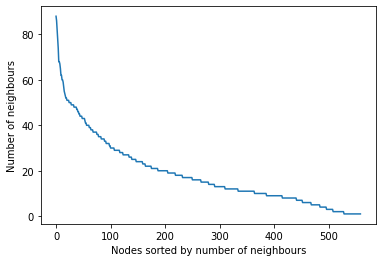

In [ ]:

from collections import defaultdict
import matplotlib.pyplot as plt


conn = defaultdict(int)
for (n1,n2,v) in edges:
  conn[n1]+=1
  conn[n2]+=1

print("There are %d neurons and %d connections"%(len(conn),len(edges)))

plt.plot(sorted(conn.values(), reverse=True))
plt.ylabel('Number of neighbours')
plt.xlabel('Nodes sorted by number of neighbours')
plt.show()


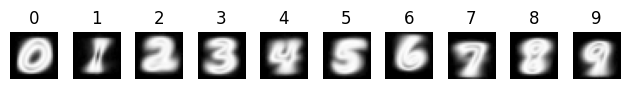

In [ ]:
import tensorflow as tf, matplotlib.pyplot as plt
#(x, y), _ = tf.keras.datasets.mnist.load_data()
for d in range(10):
    std = tf.math.reduce_std(x[y == d].astype('float32'), axis=0)
    plt.subplot(1, 10, d + 1)
    plt.imshow(std.numpy(), cmap='gray')
    plt.title(d)
    plt.axis('off')
plt.tight_layout()
plt.show()

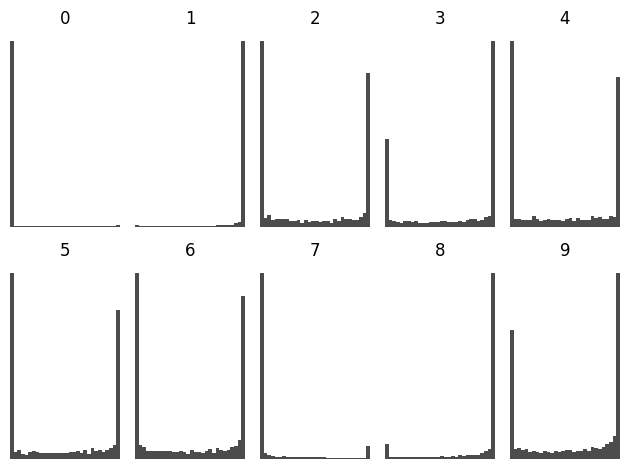

In [ ]:
import tensorflow as tf, matplotlib.pyplot as plt
(x, y), _ = tf.keras.datasets.mnist.load_data()
center = x[:, 14, 14]
for d in range(10):
    plt.subplot(2, 5, d + 1)
    plt.hist(center[y == d], bins=30, color='k', alpha=0.7, density=True, histtype='stepfilled')
    plt.title(d)
    plt.xlim(0, 255)
    plt.axis('off')
plt.tight_layout()
plt.show()

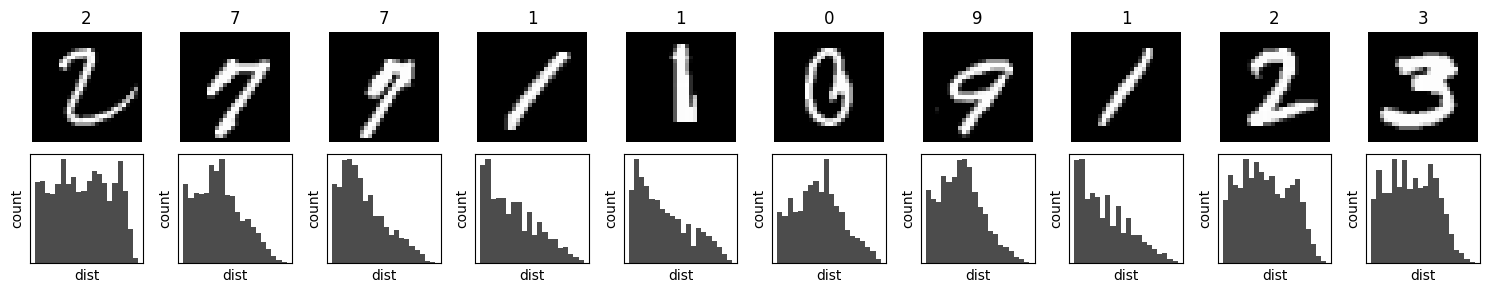

In [ ]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
(x, y), _ = tf.keras.datasets.mnist.load_data()
idx = np.random.choice(len(x), 10, replace=False)
imgs, labs = x[idx], y[idx]

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    # digit
    axes[0, i].imshow(imgs[i], cmap='gray')
    axes[0, i].set_title(labs[i]); axes[0, i].axis('off')
    # histogram
    pts = np.column_stack(np.where(imgs[i] > 127))
    if pts.shape[0] > 1:
        d = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=2)
        axes[1, i].hist(d[np.triu_indices_from(d, k=1)], bins=20,
                        color='k', alpha=0.7)
    axes[1, i].set_xlabel('dist'); axes[1, i].set_ylabel('count')
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
plt.tight_layout(); plt.show()

In [ ]:
# ===== 1.  Canvas (front-end) ==========================================
from IPython.display import HTML, display
import json, io, base64, numpy as np, matplotlib.pyplot as plt

CANVAS_SIZE = 200          # pixels
canvas_html = f"""
<canvas id="can" width="{CANVAS_SIZE}" height="{CANVAS_SIZE}"
        style="border:1px solid #000; cursor:crosshair;"></canvas>
<button onclick="stop()">Stop & plot</button>
<script>
const can = document.getElementById('can');
const ctx = can.getContext('2d');
ctx.fillStyle = '#fff'; ctx.fillRect(0, 0, {CAN_SIZE}, {CAN_SIZE});
ctx.lineWidth = 2; ctx.lineCap = 'round'; ctx.strokeStyle = '#000';

let log = [], t0 = performance.now();
let drawing = false;

can.onmousedown = e => { drawing = true; ctx.beginPath(); };
can.onmousemove = e => {
  if(!drawing) return;
  const rect = can.getBoundingClientRect();
  const x = e.clientX - rect.left;
  const y = e.clientY - rect.top;
  ctx.lineTo(x, y); ctx.stroke();
  log.push([x, y, performance.now() - t0]);   // x, y, time(ms)
};
can.onmouseup = () => drawing = false;

function stop(){
  google.colab.kernel.invokeFunction('plot_log', [JSON.stringify(log)], {});
}
</script>
"""
display(HTML(canvas_html))

# ===== 2.  Python back-end =============================================
from google.colab import output
import pandas as pd, seaborn as sns

@output.register_callback
def plot_log(json_log):
    log = pd.read_json(json_log)        # [[x,y,t], ...]
    log.columns = ['x', 'y', 't']
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # (a) pixel path
    ax[0].plot(log.x, log.y, lw=1); ax[0].set_aspect('equal')
    ax[0].set_title('Stroke path'); ax[0].invert_yaxis()
    # (b) time vs x
    ax[1].plot(log.t, log.x, lw=1); ax[1].set_xlabel('time (ms)'); ax[1].set_ylabel('x')
    plt.tight_layout(); plt.show()